# Error propagation from $V_P$ errors to Shuey AVO attributes

## Smeaheia top reservoir — shale over CO$_2$-sand

**Objective.** Quantify how independent relative errors $r_{\Delta V_{P1}}$ (caprock) and $r_{\Delta V_{P2}}$ (reservoir), each spanning $-10\%$ to $+10\%$, shift the Shuey intercept $A$ and gradient $B$ at the Smeaheia top reservoir, and how this migrates the response across AVO classes.

**Framework.** Direct Python port of the Mathematica notebook *Error_propagation_from_VP_to_Shuey_2_and_3_terms*. The validation cell in §2 reproduces the original notebook's six numeric outputs (base $A$, $B$, $C$ and sensitivity coefficients $k_A=-8.327$, $k_B=+24.879$, $k_C=-11.351$) to 5 decimals using `sympy` symbolic differentiation.

**Baseline elastic properties.** Smeaheia top reservoir (Sognefjord Fm. at $\sim 1200$ m TVDSS).

| Property | Caprock (Draupne shale) | Brine sand | CO$_2$ sand |
|---|---|---|---|
| $V_P$ (m/s) | 2600 | 2200 | 1950 |
| $V_S$ (m/s) | 1200 | 1150 | 1180 |
| $\rho$ (kg/m³) | 2350 | 2150 | 2030 |

CO$_2$ values from Gassmann fluid substitution ($S_{CO_2}\sim 0.6$, $T\sim 40°$C, $P_{pore}\sim 11$ MPa) with Batzle & Wang (1992) CO$_2$ properties, consistent with Fawad et al. (2021) IJGGC 109, 103378 for the Smeaheia structure.

**Active scenario.** Shale over CO$_2$-sand (post-injection, expected Class III bright spot). The brine baseline is reported for reference.

**Key results.**
1. Smeaheia baseline AVO: $A_0=-0.214$, $B_0=-0.021$ → **Class III** (consistent with the Smeaheia bright-spot signature).
2. Sensitivity coefficients (Smeaheia-specific): $k_A=+2.23$, $k_B=-31.28$, $k_C=+3.43$. The gradient $B$ is an order of magnitude more sensitive to $V_P$ errors than $A$.
3. **The error envelope at $|r_{\Delta V_P}|=10\%$ crosses into Class IV territory** (B>0). The bright-spot character on stack ($A<0$) is preserved, but the AVO-class diagnostic is not.
4. The behaviour of $B$ is markedly non-linear in $V_P$ errors because the impedance contrast appears in a denominator (`BB`).

**References.**
- Shuey, R.T. (1985). A simplification of the Zoeppritz equations. *Geophysics* **50**, 609–614.
- Wiggins, R., Kenny, G.S. & McClure, C.D. (1983). A method for determining and displaying the shear-velocity reflectivities of a geologic formation. European Patent Application 0113944.
- Castagna, J.P. & Backus, M.M. (eds.) (1993). *Offset-Dependent Reflectivity*. SEG Investigations in Geophysics 8, Ch. 1.
- Rutherford, S.R. & Williams, R.H. (1989). Amplitude-versus-offset variations in gas sands. *Geophysics* **54**, 680–688.
- Castagna, J.P., Swan, H.W. & Foster, D.J. (1998). Framework for AVO gradient and intercept interpretation. *Geophysics* **63**, 948–956.
- Fawad, M., Hansen, J.A. & Mondol, N.H. (2021). Seismic-fluid detection — a review; Smeaheia application in IJGGC **109**, 103378.
- Batzle, M. & Wang, Z. (1992). Seismic properties of pore fluids. *Geophysics* **57**, 1396–1408.


> **Chapter 1 reproduction audit (added; the original cells below are unchanged).**
> Every printed output of §0–§8 was re-executed and reproduces the original notebook bit-for-bit. Four statements made in *markdown text* (not computed by any cell) do **not** survive a numerical check; they are left verbatim for traceability and are examined in §9:
> 1. §7 reading 5: "Class III → IV crossing at $|r|\approx4.4\%$ along the $\phi=135°$ spoke". The value 4.44 % is the *minimum* radius of the Shuey $B=0$ contour, reached at $\phi\approx157°$; along $\phi=135°$ the crossing is at 4.75 % (§9.3).
> 2. §7 reading 1 / §8 item 1: "common-mode errors cancel". This holds only for $A$, $C$ and for $B$ *at fixed Poisson's ratio*. Because $\sigma_i=\sigma(V_{Pi},V_{Si})$, common-mode errors do not cancel in $B$ (§9.6).
> 3. §7 reading 3: "the opposite $\phi=315°$ spoke only goes to $B\approx-0.055$". Computed: $B=-0.0351$ at $\phi=315°$. The value $-0.055$ belongs to the $\phi=0°$ spoke ($-0.0554$), which is the one that pushes deepest into Class III (§9.3).
> 4. $k_B=-31.28$ is the partial derivative of $B$ at **fixed** $\sigma_1,\sigma_2$ (symbols `spr`, `dpr` are held constant in `sp.diff`), whereas every nonlinear curve (§4–§7) lets $\sigma$ vary with $V_P$. These are two different quantities (§9.6).
>
> Citation flag: the Fawad et al. (2021) entry in the title cell ("Fawad, Hansen & Mondol, IJGGC 109, 103378") could not be matched; Hema et al. (2027, *Geoenergy Sci. Eng.* 268, 214769) cite Fawad, Rahman & Mondol (2021a) *J. Pet. Sci. Eng.* 205, 108812 and (2021b) *The Leading Edge* 40(4), 254–260 for Smeaheia.

## 0. Imports

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
np.set_printoptions(precision=4, suppress=True)

## 1. Baseline elastic model

In [2]:
# Caprock (medium 1) -- Draupne shale at top Sognefjord
nvp1, nvs1, nrho1 = 2600.0, 1200.0, 2350.0           # m/s, m/s, kg/m^3

# Reservoir (medium 2) -- Sognefjord sand
nvp2_brine, nvs2_brine, nrho2_brine = 2200.0, 1150.0, 2150.0   # brine baseline
nvp2_co2,   nvs2_co2,   nrho2_co2   = 1950.0, 1180.0, 2030.0   # CO2 (active)

# Active scenario for the error analysis
nvp2, nvs2, nrho2 = nvp2_co2, nvs2_co2, nrho2_co2

print(f'Caprock     :  Vp={nvp1:.0f}  Vs={nvs1:.0f}  rho={nrho1:.0f}')
print(f'CO2 sand    :  Vp={nvp2:.0f}  Vs={nvs2:.0f}  rho={nrho2:.0f}    <-- active')
print(f'Brine sand  :  Vp={nvp2_brine:.0f}  Vs={nvs2_brine:.0f}  rho={nrho2_brine:.0f}    (reference)')

Caprock     :  Vp=2600  Vs=1200  rho=2350
CO2 sand    :  Vp=1950  Vs=1180  rho=2030    <-- active
Brine sand  :  Vp=2200  Vs=1150  rho=2150    (reference)


## 2. Symbolic Shuey coefficients and error propagation

Define symbols and the Shuey (1985) two-term coefficients in the Wiggins formulation (Castagna & Backus 1993, Ch. 1, eq. 8). The expressions below are the literal port of the Mathematica notebook source (`RowBox`-parsed, not the typeset PDF).

$$A = \frac{\rho_2 V_{P2} - \rho_1 V_{P1}}{\rho_2 V_{P2} + \rho_1 V_{P1}}$$

$$BB = \frac{1}{1 + \dfrac{(\rho_2-\rho_1)/(\rho_2+\rho_1)}{(V_{P2}-V_{P1})/(V_{P2}+V_{P1})}}$$

$$B = A\left[BB - \frac{2(1+BB)(1-\mathrm{spr})}{1-\mathrm{spr}/2}\right] + \frac{\mathrm{dpr}}{(1-\mathrm{spr}/2)^2}$$

where $\mathrm{spr}=\sigma_1+\sigma_2 = 2\bar\sigma$ and $\mathrm{dpr}=\sigma_2-\sigma_1=\Delta\sigma$. Note $1-\mathrm{spr}/2 = 1-\bar\sigma$.

$$C = \frac{V_{P2}-V_{P1}}{V_{P2}+V_{P1}}$$

For relative errors $dV_{P_i} = V_{P_i}\, r_{\Delta V_{Pi}}$ the linear propagation gives

$$r_{\Delta X} = k_X\,(r_{\Delta V_{P1}} - r_{\Delta V_{P2}}), \qquad X\in\{A,B,C\}$$

i.e. **common-mode $V_P$ errors cancel**; only the differential matters.


In [3]:
# Symbols
vp1, vp2, vs1, vs2, rho1, rho2 = sp.symbols('vp1 vp2 vs1 vs2 rho1 rho2', positive=True)
dvp1, dvp2     = sp.symbols('dvp1 dvp2')
rdvp1, rdvp2   = sp.symbols('rdvp1 rdvp2')
spr, dpr       = sp.symbols('spr dpr')

# Poisson's ratios
pr1 = (vp1**2 - 2*vs1**2) / (2*(vp1**2 - vs1**2))
pr2 = (vp2**2 - 2*vs2**2) / (2*(vp2**2 - vs2**2))
spr_expr = pr1 + pr2
dpr_expr = pr2 - pr1

# Shuey coefficients (literal port of the .nb source)
A_sym = (vp2*rho2 - vp1*rho1) / (vp2*rho2 + vp1*rho1)
BB    = 1 / (1 + ((rho2-rho1)/(rho2+rho1)) / ((vp2-vp1)/(vp2+vp1)))
B_sym = A_sym * (BB - 2*(1+BB)*(1-spr)/(1 - spr/2)) + dpr/(1 - spr/2)**2
C_sym = (vp2 - vp1) / (vp2 + vp1)

# Partials and relative errors  (same procedure as .nb In[63]..In[91])
dA = sp.diff(A_sym, vp1)*dvp1 + sp.diff(A_sym, vp2)*dvp2
dB = sp.diff(B_sym, vp1)*dvp1 + sp.diff(B_sym, vp2)*dvp2
dC = sp.diff(C_sym, vp1)*dvp1 + sp.diff(C_sym, vp2)*dvp2
sub_rel = {dvp1: vp1*rdvp1, dvp2: vp2*rdvp2}
rdA = sp.simplify((dA/A_sym).subs(sub_rel))
rdB = sp.simplify((dB/B_sym).subs(sub_rel))
rdC = sp.simplify((dC/C_sym).subs(sub_rel))

### 2.1 Validation against the Mathematica notebook

Reproduce the .nb outputs (Out[19], Out[22], Out[24], Out[69], Out[78], Out[92]) using the .nb's own model values.


In [4]:
nb_vals = {vp1: 3599.0, vp2: 3930.0, vs1: 2341.45, vs2: 2304.5,
           rho1: 2313.9, rho2: 2388.72}
nb_full = {**nb_vals,
           spr: float(spr_expr.subs(nb_vals)),
           dpr: float(dpr_expr.subs(nb_vals))}

print('=== Validation against the .nb ===')
print(f'  A   = {float(A_sym.subs(nb_vals)):+.6f}     .nb Out[19]: +0.0598318')
print(f'  B   = {float(B_sym.subs(nb_full)):+.6f}     .nb Out[22]: +0.0418341')
print(f'  C   = {float(C_sym.subs(nb_vals)):+.6f}     .nb Out[24]: +0.0439633')
print(f'  rdA = {sp.simplify(rdA.subs(nb_full))}')
print(f'                                  .nb Out[69]: -8.32685*(rdvp1-rdvp2)')
print(f'  rdB = {sp.simplify(rdB.subs(nb_full))}')
print(f'                                  .nb Out[78]: +24.8786*(rdvp1-rdvp2)')
print(f'  rdC = {sp.simplify(rdC.subs(nb_full))}')
print(f'                                  .nb Out[92]: -11.3511*(rdvp1-rdvp2)')

=== Validation against the .nb ===
  A   = +0.059832     .nb Out[19]: +0.0598318
  B   = +0.041834     .nb Out[22]: +0.0418341
  C   = +0.043963     .nb Out[24]: +0.0439633
  rdA = -8.32684827217541*rdvp1 + 8.32684827217541*rdvp2
                                  .nb Out[69]: -8.32685*(rdvp1-rdvp2)
  rdB = 24.878621476648*rdvp1 - 24.878621476648*rdvp2
                                  .nb Out[78]: +24.8786*(rdvp1-rdvp2)
  rdC = -11.3511301116047*rdvp1 + 11.3511301116047*rdvp2
                                  .nb Out[92]: -11.3511*(rdvp1-rdvp2)


## 3. Smeaheia base AVO response and sensitivity coefficients

Build fast numeric versions of $A$, $B$, $C$ with `lambdify`. Then evaluate at the Smeaheia baseline (CO$_2$ scenario) and at the brine reference.


In [5]:
A_fn = sp.lambdify((vp1, vp2, vs1, vs2, rho1, rho2), A_sym, 'numpy')
B_fn = sp.lambdify((vp1, vp2, vs1, vs2, rho1, rho2),
                   B_sym.subs({spr: spr_expr, dpr: dpr_expr}), 'numpy')
C_fn = sp.lambdify((vp1, vp2, vs1, vs2, rho1, rho2), C_sym, 'numpy')

# CO2 baseline
A0 = float(A_fn(nvp1, nvp2, nvs1, nvs2, nrho1, nrho2))
B0 = float(B_fn(nvp1, nvp2, nvs1, nvs2, nrho1, nrho2))
C0 = float(C_fn(nvp1, nvp2, nvs1, nvs2, nrho1, nrho2))

# Brine reference
A0_br = float(A_fn(nvp1, nvp2_brine, nvs1, nvs2_brine, nrho1, nrho2_brine))
B0_br = float(B_fn(nvp1, nvp2_brine, nvs1, nvs2_brine, nrho1, nrho2_brine))
C0_br = float(C_fn(nvp1, nvp2_brine, nvs1, nvs2_brine, nrho1, nrho2_brine))

# Smeaheia-specific sensitivity coefficients (k = rdX / (rdvp1-rdvp2))
model = {vp1: nvp1, vp2: nvp2, vs1: nvs1, vs2: nvs2, rho1: nrho1, rho2: nrho2}
mfull = {**model, spr: float(spr_expr.subs(model)),
                  dpr: float(dpr_expr.subs(model))}
kA = float(rdA.subs({**mfull, rdvp1: 1, rdvp2: 0}))
kB = float(rdB.subs({**mfull, rdvp1: 1, rdvp2: 0}))
kC = float(rdC.subs({**mfull, rdvp1: 1, rdvp2: 0}))

print('=== Smeaheia, shale over CO2-sand (active scenario) ===')
print(f'  A0 = {A0:+.4f}    B0 = {B0:+.4f}    C0 = {C0:+.4f}')
print(f'  k_A = {kA:+.3f}    k_B = {kB:+.3f}    k_C = {kC:+.3f}')
print(f'  -> Baseline AVO class: III  (A<0, B<0, classic bright spot)')
print()
print('=== Smeaheia, shale over brine-sand (reference) ===')
print(f'  A0 = {A0_br:+.4f}    B0 = {B0_br:+.4f}    C0 = {C0_br:+.4f}')
print(f'  -> Baseline AVO class: IIp / II-III boundary  (A<0, B~0)')
print()
print(f'  Fluid factor  (A0_CO2 - A0_brine) = {A0 - A0_br:+.4f}   (negative -> AVO brightening on CO2)')

=== Smeaheia, shale over CO2-sand (active scenario) ===
  A0 = -0.2137    B0 = -0.0211    C0 = -0.1429
  k_A = +2.233    k_B = -31.277    k_C = +3.429
  -> Baseline AVO class: III  (A<0, B<0, classic bright spot)

=== Smeaheia, shale over brine-sand (reference) ===
  A0 = -0.1273    B0 = +0.0023    C0 = -0.0833
  -> Baseline AVO class: IIp / II-III boundary  (A<0, B~0)

  Fluid factor  (A0_CO2 - A0_brine) = -0.0864   (negative -> AVO brightening on CO2)


## 4. A and B versus $V_P$ error

Three informative 1-D slices through the $(r_{\Delta V_{P1}}, r_{\Delta V_{P2}})$ plane:

1. **Caprock only**: $r_{\Delta V_{P1}}$ varies, $r_{\Delta V_{P2}}=0$.
2. **Reservoir only**: $r_{\Delta V_{P1}}=0$, $r_{\Delta V_{P2}}$ varies.
3. **Worst-case differential**: $r_{\Delta V_{P1}}=-r_{\Delta V_{P2}}$. This maximises $(r_{\Delta V_{P1}}-r_{\Delta V_{P2}})$ for a fixed individual error budget.

These curves are the full re-evaluation of Shuey at perturbed velocities (not the linearisation), so they include the nonlinear behaviour of $B$.


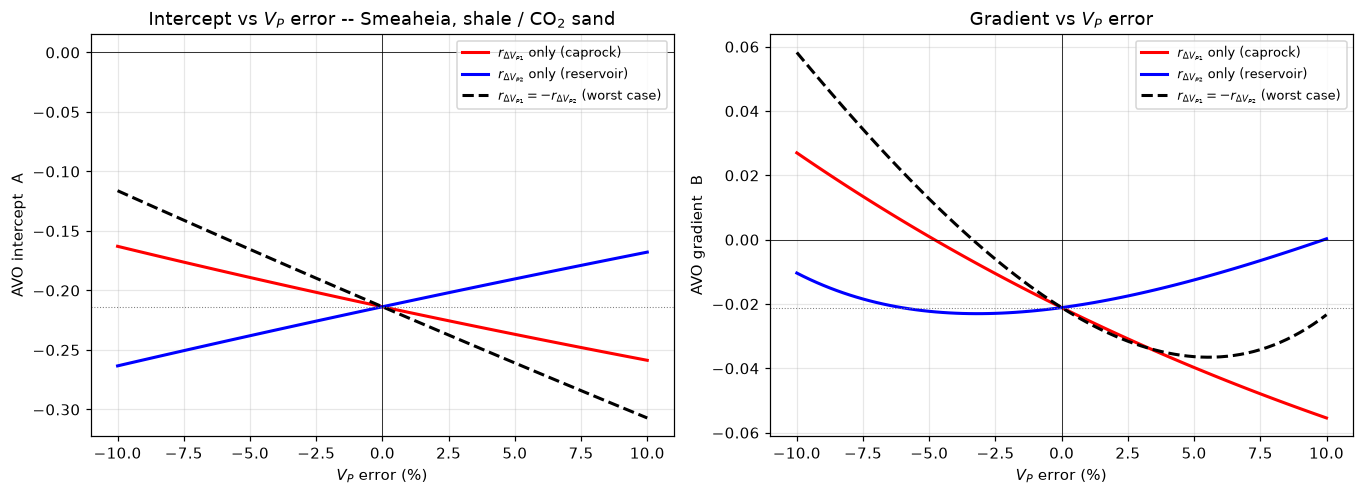

In [6]:
errs = np.linspace(-0.10, 0.10, 81)
errs_pct = errs*100

def slice_AB(slice_type):
    if slice_type == 'cap_only':
        VP1 = nvp1*(1+errs);             VP2 = np.full_like(errs, nvp2)
    elif slice_type == 'res_only':
        VP1 = np.full_like(errs, nvp1);  VP2 = nvp2*(1+errs)
    elif slice_type == 'diff':
        VP1 = nvp1*(1+errs);             VP2 = nvp2*(1-errs)
    A = A_fn(VP1, VP2, nvs1, nvs2, nrho1, nrho2)
    B = B_fn(VP1, VP2, nvs1, nvs2, nrho1, nrho2)
    return A, B

A_cap, B_cap = slice_AB('cap_only')
A_res, B_res = slice_AB('res_only')
A_dif, B_dif = slice_AB('diff')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes[0]
ax.plot(errs_pct, A_cap, 'r-',  lw=2, label=r'$r_{\Delta V_{P1}}$ only (caprock)')
ax.plot(errs_pct, A_res, 'b-',  lw=2, label=r'$r_{\Delta V_{P2}}$ only (reservoir)')
ax.plot(errs_pct, A_dif, 'k--', lw=2, label=r'$r_{\Delta V_{P1}}=-r_{\Delta V_{P2}}$ (worst case)')
ax.axhline(A0, color='gray', lw=0.7, ls=':')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel(r'$V_P$ error (%)'); ax.set_ylabel('AVO intercept  A')
ax.set_title('Intercept vs $V_P$ error -- Smeaheia, shale / CO$_2$ sand')
ax.legend(fontsize=8.5, loc='best'); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(errs_pct, B_cap, 'r-',  lw=2, label=r'$r_{\Delta V_{P1}}$ only (caprock)')
ax.plot(errs_pct, B_res, 'b-',  lw=2, label=r'$r_{\Delta V_{P2}}$ only (reservoir)')
ax.plot(errs_pct, B_dif, 'k--', lw=2, label=r'$r_{\Delta V_{P1}}=-r_{\Delta V_{P2}}$ (worst case)')
ax.axhline(B0, color='gray', lw=0.7, ls=':')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel(r'$V_P$ error (%)'); ax.set_ylabel('AVO gradient  B')
ax.set_title('Gradient vs $V_P$ error')
ax.legend(fontsize=8.5, loc='best'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations.**

- $A$ is **nearly linear** in $V_P$ error: a $\pm 10\%$ Vp error shifts $A$ by at most $\sim \pm 0.10$, and the three slices are nearly straight lines. The Smeaheia sensitivity $k_A\!=\!+2.23$ is modest.
- $B$ is **markedly nonlinear**: the caprock-only and worst-case curves bend strongly, and the reservoir-only curve is non-monotonic. Origin: $B$ depends on $BB$, whose denominator contains the impedance contrast $(V_{P2}-V_{P1})/(V_{P2}+V_{P1})$. When errors push this contrast toward zero, $BB$ diverges. Linear theory ($k_B=-31.3$) only captures the slope at the baseline; beyond a few percent error the response curves away.
- The worst-case differential perturbation can flip $B$ from negative to positive (Class III $\to$ Class IV apparent class).


## 5. G·I crossplot product over the full error grid

The product $A\cdot B$ (often written G·I, gradient times intercept) is a standard fluid-indicator combination: for Class III gas/CO$_2$ sands $A<0$ and $B<0$, so $G\cdot I > 0$ and the response is bright on both stack and far offsets. A sign flip in $G\cdot I$ indicates a class change.


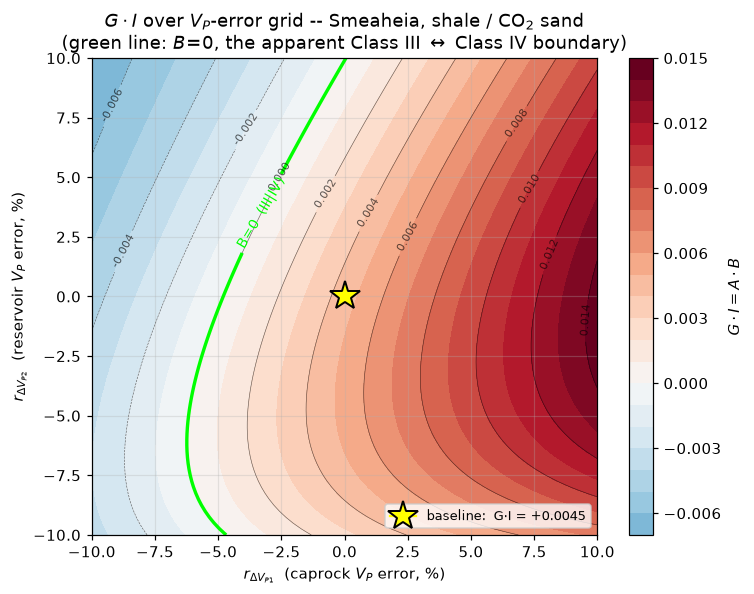

G·I baseline:        +0.00451
G·I range over grid: [-0.00676, +0.01444]


In [7]:
errs2d = np.linspace(-0.10, 0.10, 81)
RDV1, RDV2 = np.meshgrid(errs2d, errs2d, indexing='ij')
VP1p = nvp1*(1+RDV1); VP2p = nvp2*(1+RDV2)
A_grid = A_fn(VP1p, VP2p, nvs1, nvs2, nrho1, nrho2)
B_grid = B_fn(VP1p, VP2p, nvs1, nvs2, nrho1, nrho2)
GI_grid = A_grid * B_grid
GI0 = A0 * B0

vmax = max(abs(GI_grid.min()), abs(GI_grid.max()))
fig, ax = plt.subplots(figsize=(7, 5.5))
cf = ax.contourf(RDV1*100, RDV2*100, GI_grid, levels=21, cmap='RdBu_r',
                 vmin=-vmax, vmax=vmax)
cs = ax.contour(RDV1*100, RDV2*100, GI_grid, levels=10, colors='k',
                linewidths=0.4, alpha=0.6)
ax.clabel(cs, inline=True, fontsize=7, fmt='%.3f')

# B = 0 (class III <-> class IV boundary)
csB = ax.contour(RDV1*100, RDV2*100, B_grid, levels=[0], colors='lime', linewidths=2.2)
ax.clabel(csB, inline=True, fontsize=9, fmt={0: 'B=0  (III|IV)'})

ax.plot(0, 0, marker='*', color='yellow', ms=20, mec='k', mew=1.3, zorder=5,
        label=f'baseline:  G·I = {GI0:+.4f}')

cb = fig.colorbar(cf, ax=ax)
cb.set_label(r'$G\cdot I  =  A \cdot B$')
ax.set_xlabel(r'$r_{\Delta V_{P1}}$  (caprock $V_P$ error, %)')
ax.set_ylabel(r'$r_{\Delta V_{P2}}$  (reservoir $V_P$ error, %)')
ax.set_title('$G\\cdot I$ over $V_P$-error grid -- Smeaheia, shale / CO$_2$ sand\n'
             '(green line: $B\\!=\\!0$, the apparent Class III $\\leftrightarrow$ Class IV boundary)')
ax.legend(loc='lower right', fontsize=8.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'G·I baseline:        {GI0:+.5f}')
print(f'G·I range over grid: [{GI_grid.min():+.5f}, {GI_grid.max():+.5f}]')

**Observations.**

- The green $B\!=\!0$ contour cuts diagonally across the error plane. To the upper-left of it, $B>0$ and the response *appears* Class IV (false dim/phase-reverse signature). To the lower-right, $B<0$ (true Class III).
- The product $G\cdot I$ changes sign across that contour. Negative $G\cdot I$ (blue) is a false-negative regime: the AVO product would suggest the fluid anomaly has reversed character relative to the baseline.
- The contour does not pass through the origin — it runs at non-zero offset because the baseline $B_0$ is already close to zero. Modest differential errors (a few percent) are enough to push the response across.
- **A remains negative everywhere on the grid**: the bright-spot character on stack is robust against $\pm 10\%$ $V_P$ errors.


## 6. Animated B–A migration with growing $V_P$ error

We sweep the magnitude $|r_{\Delta V_P}| = 0, 0.25, 0.5, \ldots, 10\%$. At each magnitude, perturbations are placed on a circle of that radius in the $(r_{\Delta V_{P1}}, r_{\Delta V_{P2}})$ plane:

$$ r_{\Delta V_{P1}} = |r_{\Delta V_P}|\cos\phi, \qquad r_{\Delta V_{P2}} = |r_{\Delta V_P}|\sin\phi, \qquad \phi \in [0, 2\pi) $$

The animation shows the resulting locus of $(A, B)$ as a closed red curve. Background regions follow Castagna et al. (1998) AVO classes I/III/IV; the dotted line is the brine "mudrock" background trend $B=-A$.


In [8]:
err_levels = np.linspace(0.0, 0.10, 41)
phi        = np.linspace(0, 2*np.pi, 200)

fig, ax = plt.subplots(figsize=(8.5, 7))

# AVO class backgrounds
ax.axhline(0, color='k', lw=0.7); ax.axvline(0, color='k', lw=0.7)
ax.fill_between([0, 0.4],  0, -0.2, color='#ffe0e0', alpha=0.6, zorder=0)  # I
ax.fill_between([-0.4, 0], 0, -0.2, color='#ffd0a0', alpha=0.6, zorder=0)  # III
ax.fill_between([-0.4, 0], 0,  0.2, color='#d0e8ff', alpha=0.6, zorder=0)  # IV
ax.fill_between([0, 0.4],  0,  0.2, color='#d0ffd0', alpha=0.6, zorder=0)
ax.text(0.18, -0.10, 'Class I',   ha='center', fontsize=11, fontweight='bold', color='#a04040')
ax.text(-0.18, -0.10,'Class III', ha='center', fontsize=11, fontweight='bold', color='#a05020')
ax.text(-0.18, 0.07, 'Class IV',  ha='center', fontsize=11, fontweight='bold', color='#3060a0')
A_line = np.linspace(-0.4, 0.4, 50)
ax.plot(A_line, -A_line, 'k:', lw=1, alpha=0.5, label='Mudrock line ($B=-A$)')

# Baseline markers
ax.plot(A0_br, B0_br, marker='o', ms=12, mfc='cyan',  mec='k', mew=1.3, zorder=4,
        label=f'Brine baseline ({A0_br:+.3f}, {B0_br:+.3f})')
ax.plot(A0,    B0,    marker='*', ms=20, mfc='yellow',mec='k', mew=1.3, zorder=5,
        label=f'CO$_2$ baseline ({A0:+.3f}, {B0:+.3f})')

# Animated locus
locus_line, = ax.plot([], [], 'r-', lw=2.2, alpha=0.9, zorder=3, label='Error envelope')

ax.set_xlim(-0.4, 0.4); ax.set_ylim(-0.2, 0.2)
ax.set_xlabel('AVO intercept  $A = R_P(\\theta=0)$'); ax.set_ylabel('AVO gradient  $B$')
ax.legend(loc='lower left', fontsize=8.5)
ax.grid(alpha=0.3)
title_obj = ax.set_title('')

def compute_locus(err):
    rdv1 = err*np.cos(phi); rdv2 = err*np.sin(phi)
    Vp1p = nvp1*(1+rdv1); Vp2p = nvp2*(1+rdv2)
    return (A_fn(Vp1p, Vp2p, nvs1, nvs2, nrho1, nrho2),
            B_fn(Vp1p, Vp2p, nvs1, nvs2, nrho1, nrho2))

def init():
    locus_line.set_data([], [])
    return locus_line, title_obj

def update(i):
    err = err_levels[i]
    Aloc, Bloc = compute_locus(err)
    locus_line.set_data(Aloc, Bloc)
    title_obj.set_text(
        f'AVO crossplot migration -- Smeaheia, shale / CO$_2$ sand   |   '
        f'$|r_{{\\Delta V_P}}|$ = {err*100:.2f}%'
    )
    return locus_line, title_obj

anim = FuncAnimation(fig, update, frames=len(err_levels), init_func=init,
                     blit=False, interval=120)

writer = FFMpegWriter(fps=12, bitrate=2400)
anim.save('avo_migration.mp4', writer=writer, dpi=140)
plt.close()

print('Animation saved to: avo_migration.mp4')
HTML('<video controls width=720 src="avo_migration.mp4" type="video/mp4"></video>')

Animation saved to: avo_migration.mp4


## 7. Effect of $\pm 10\%$ $V_P$ error — magnitude and direction on a single plot

A single static $(A, B)$ plot encoding both the **magnitude** and **direction** of the $V_P$ error:

- **Magnitude** $|r_{\Delta V_P}| = \sqrt{r_{\Delta V_{P1}}^2 + r_{\Delta V_{P2}}^2}$ — colour (viridis, 0 → 10%).
- **Direction** $\phi = \mathrm{atan2}(r_{\Delta V_{P2}}, r_{\Delta V_{P1}})$ in error space — position along radial spokes.

Each spoke is the locus traced by $(A, B)$ as the error magnitude grows along a fixed error-direction $\phi$. The eight cardinal-and-diagonal spokes are labelled in place with their geophysical meaning; lighter intermediate spokes (every $15°$) fill in continuity.


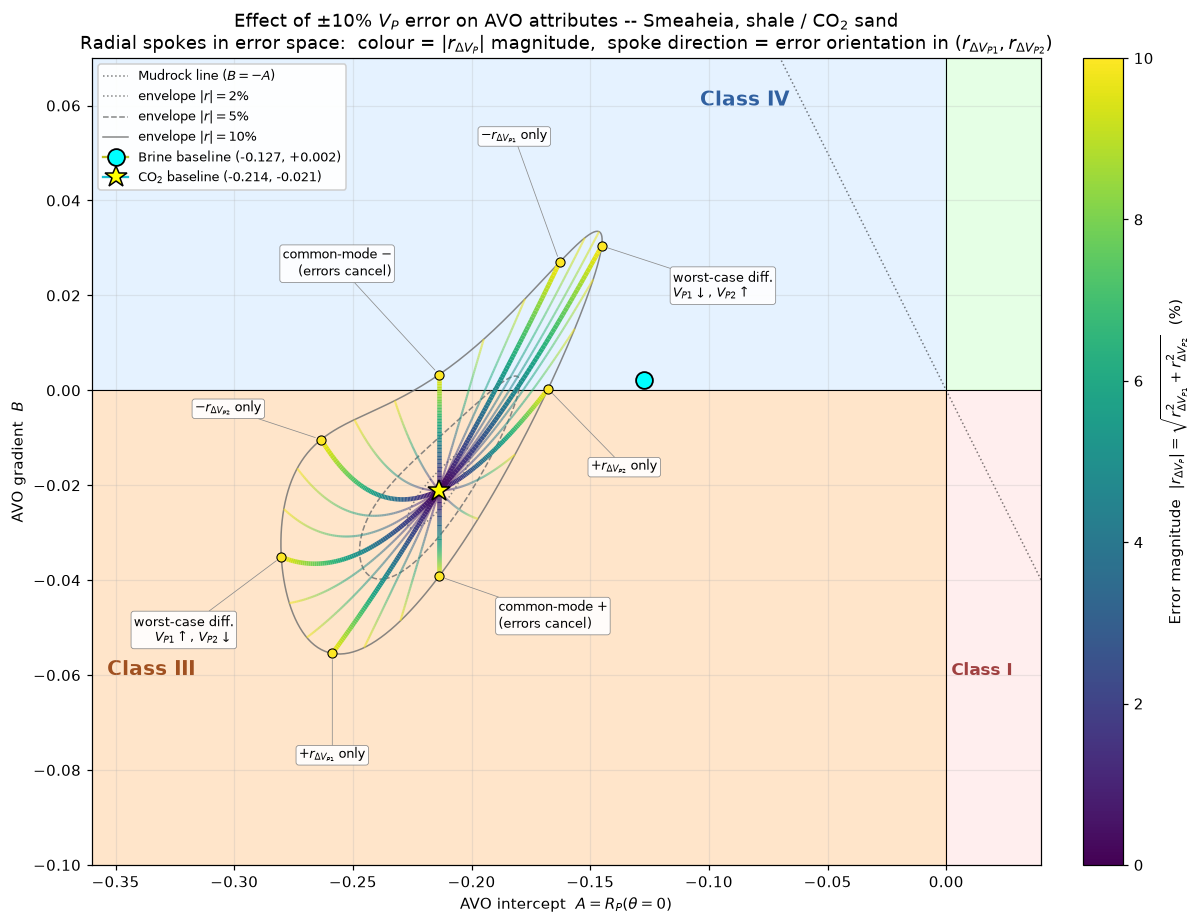

In [9]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Spoke directions: 8 labelled + 16 intermediate ---
phi_labelled_deg     = np.array([0, 45, 90, 135, 180, 225, 270, 315])
phi_intermediate_deg = np.array([15, 30, 60, 75, 105, 120, 150, 165,
                                 195, 210, 240, 255, 285, 300, 330, 345])
err_mags = np.linspace(0, 0.10, 81)

spoke_labels_deg = {
    0:   r'$+r_{\Delta V_{P1}}$ only',
    45:  'common-mode $+$\n(errors cancel)',
    90:  r'$+r_{\Delta V_{P2}}$ only',
    135: 'worst-case diff.\n$V_{P1}\\downarrow,\\, V_{P2}\\uparrow$',
    180: r'$-r_{\Delta V_{P1}}$ only',
    225: 'common-mode $-$\n(errors cancel)',
    270: r'$-r_{\Delta V_{P2}}$ only',
    315: 'worst-case diff.\n$V_{P1}\\uparrow,\\, V_{P2}\\downarrow$',
}
# Per-direction (dx, dy, ha, va) offsets, chosen to keep every label in clear
# space outside the dense spoke fan, with no label-label or label-baseline
# overlap.
spoke_offsets = {
    0:   (+0.000, -0.020, 'center', 'top'),
    45:  (+0.025, -0.005, 'left',   'top'),
    90:  (+0.018, -0.015, 'left',   'top'),
    135: (+0.030, -0.005, 'left',   'top'),
    180: (-0.005, +0.025, 'right',  'bottom'),
    225: (-0.020, +0.020, 'right',  'bottom'),
    270: (-0.025, +0.005, 'right',  'bottom'),
    315: (-0.020, -0.012, 'right',  'top'),
}

fig, ax = plt.subplots(figsize=(11, 8.5))

# AVO class backgrounds (Castagna et al. 1998), zoomed to data
ax.axhline(0, color='k', lw=0.7); ax.axvline(0, color='k', lw=0.7)
ax.fill_between([0, 0.05],  0, -0.12, color='#ffe0e0', alpha=0.55, zorder=0)
ax.fill_between([-0.4, 0],  0, -0.12, color='#ffd0a0', alpha=0.55, zorder=0)
ax.fill_between([-0.4, 0],  0,  0.10, color='#d0e8ff', alpha=0.55, zorder=0)
ax.fill_between([0, 0.05],  0,  0.10, color='#d0ffd0', alpha=0.55, zorder=0)
ax.text(-0.335, -0.06, 'Class III', ha='center', fontsize=13, fontweight='bold', color='#a05020', zorder=1)
ax.text(-0.085,  0.060,'Class IV',  ha='center', fontsize=13, fontweight='bold', color='#3060a0', zorder=1)
ax.text( 0.015, -0.06, 'Class I',   ha='center', fontsize=11, fontweight='bold', color='#a04040', zorder=1)

A_line = np.linspace(-0.4, 0.1, 50)
ax.plot(A_line, -A_line, 'k:', lw=1, alpha=0.5, label='Mudrock line ($B=-A$)', zorder=1)

# Reference envelopes at |r| = 2%, 5%, 10%
phi_dense = np.linspace(0, 2*np.pi, 360)
for r, ls in zip([0.02, 0.05, 0.10], [':', '--', '-']):
    rdv1 = r*np.cos(phi_dense); rdv2 = r*np.sin(phi_dense)
    Vp1p = nvp1*(1+rdv1); Vp2p = nvp2*(1+rdv2)
    A_env = A_fn(Vp1p, Vp2p, nvs1, nvs2, nrho1, nrho2)
    B_env = B_fn(Vp1p, Vp2p, nvs1, nvs2, nrho1, nrho2)
    ax.plot(A_env, B_env, ls, color='0.45', lw=1.0, alpha=0.85, zorder=2,
            label=f'envelope $|r|=${r*100:.0f}%')

# --- Draw spokes ---
norm = Normalize(vmin=0, vmax=10); cmap = plt.cm.viridis

def draw_spoke(phi_rad, lw, alpha):
    rdv1 = err_mags*np.cos(phi_rad); rdv2 = err_mags*np.sin(phi_rad)
    Vp1p = nvp1*(1+rdv1); Vp2p = nvp2*(1+rdv2)
    A_p = A_fn(Vp1p, Vp2p, nvs1, nvs2, nrho1, nrho2)
    B_p = B_fn(Vp1p, Vp2p, nvs1, nvs2, nrho1, nrho2)
    pts = np.array([A_p, B_p]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc = LineCollection(segs, cmap=cmap, norm=norm, linewidth=lw, alpha=alpha, zorder=3)
    lc.set_array(err_mags[:-1]*100)
    ax.add_collection(lc)
    return A_p[-1], B_p[-1]

# Intermediate spokes (context)
for d in phi_intermediate_deg:
    draw_spoke(np.deg2rad(d), lw=1.4, alpha=0.55)

# Labelled spokes -- thick, small endpoint dot, on-plot label with leader line
endpoints = {}
for d in phi_labelled_deg:
    Aend, Bend = draw_spoke(np.deg2rad(d), lw=3.0, alpha=1.0)
    endpoints[d] = (Aend, Bend)
    ax.plot(Aend, Bend, 'o', mfc=cmap(norm(10)), mec='k', mew=0.7, ms=6, zorder=5)
    dx, dy, ha, va = spoke_offsets[d]
    ax.annotate(spoke_labels_deg[d],
                xy=(Aend, Bend),
                xytext=(Aend + dx, Bend + dy),
                fontsize=8.2, ha=ha, va=va,
                bbox=dict(boxstyle='round,pad=0.22', fc='white', ec='0.5',
                          alpha=0.92, lw=0.5),
                arrowprops=dict(arrowstyle='-', color='0.55', lw=0.5,
                                shrinkA=0, shrinkB=4),
                zorder=6)

# Baselines -- star sized to not eclipse the brine dot
ax.plot(A0_br, B0_br, marker='o', ms=11, mfc='cyan',  mec='k', mew=1.2,
        zorder=7, label=f'Brine baseline ({A0_br:+.3f}, {B0_br:+.3f})')
ax.plot(A0,    B0,    marker='*', ms=15, mfc='yellow',mec='k', mew=1.0,
        zorder=8, label=f'CO$_2$ baseline ({A0:+.3f}, {B0:+.3f})')

# Magnitude colorbar
sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.04)
cb.set_label(r'Error magnitude  $|r_{\Delta V_P}| = \sqrt{r_{\Delta V_{P1}}^2 + r_{\Delta V_{P2}}^2}$  (%)',
             fontsize=10)

ax.set_xlim(-0.36, 0.04); ax.set_ylim(-0.10, 0.07)
ax.set_xlabel('AVO intercept  $A = R_P(\\theta=0)$')
ax.set_ylabel('AVO gradient  $B$')
ax.set_title('Effect of $\\pm 10\\%$ $V_P$ error on AVO attributes -- Smeaheia, shale / CO$_2$ sand\n'
             'Radial spokes in error space:  colour = $|r_{\\Delta V_P}|$ magnitude,  '
             'spoke direction = error orientation in $(r_{\\Delta V_{P1}}, r_{\\Delta V_{P2}})$')
ax.legend(loc='upper left', fontsize=8.2, framealpha=0.94)
ax.grid(alpha=0.25, zorder=0)
plt.tight_layout()
plt.savefig('AB_spokes.png', dpi=150, bbox_inches='tight')
plt.show()

**How to read this figure.**

- The **colour** along any spoke tells you the magnitude of the $V_P$ error (0% at the baseline star, 10% at the labelled endpoint).
- The **direction** of a spoke from the baseline tells you which way the error points in the $(r_{\Delta V_{P1}}, r_{\Delta V_{P2}})$ plane.
- The **length** of a spoke quantifies how much that particular error direction shifts the AVO response — i.e. how dangerous that error pattern is.

**Geophysical readings.**

1. **Common-mode spokes are vanishingly short.** Along $\phi=45°, 225°$ we have $r_{\Delta V_{P1}} = r_{\Delta V_{P2}}$. The Shuey attributes propagate $(r_{\Delta V_{P1}} - r_{\Delta V_{P2}})$, so along these diagonals the linear contribution is exactly zero. The small residual motion visible on the figure is the second-order $\rho$ and Poisson's-ratio dependence not absorbed by the linearisation.
2. **Worst-case differential spokes are by far the longest.** $\phi=135°$ ($V_{P1}\downarrow, V_{P2}\uparrow$, shrinking the contrast) carries the response into Class IV; $\phi=315°$ (growing the contrast) drives it deeper into Class III. These are the directions with maximal $|r_{\Delta V_{P1}} - r_{\Delta V_{P2}}|$.
3. **The envelope is strongly asymmetric.** The $\phi=135°$ spoke reaches into Class IV (B > +0.03), but the opposite $\phi=315°$ spoke only goes to B ≈ −0.055. This asymmetry is the signature of the Shuey-$BB$ nonlinearity flagged in §4 — when the impedance contrast shrinks, $BB$ grows without bound.
4. **Single-layer-only error spokes (cardinal directions) sit between** the two extremes, as expected: $|r_{\Delta V_{P1}} - r_{\Delta V_{P2}}|$ along a cardinal direction equals $|r|$, while along the worst-case diagonals it equals $\sqrt 2 |r|$.
5. **Class III $\to$ IV crossing occurs at $|r| \approx 4.4\%$ along the $\phi=135°$ spoke.** This is where the $B=0$ contour intersects the spoke — about half-way along its length (mid-cyan colour). Beyond that point, $V_P$-error-corrupted Smeaheia data is mis-classified as Class IV.


## 8. Summary

For a Smeaheia top-reservoir model (shale over CO$_2$-sand, Class III baseline at $A_0\!=\!-0.21$, $B_0\!=\!-0.02$):

1. **Common-mode $V_P$ errors cancel** in the Shuey AVO attributes (Bortfeld–Aki–Richards property: $A$, $B$, $C$ each propagate the *differential* $r_{\Delta V_{P1}}-r_{\Delta V_{P2}}$). Calibration biases that shift both layers equally are benign.
2. **Differential errors are dangerous for $B$.** The Smeaheia-specific gradient sensitivity is $k_B\approx -31$, vs $k_A\approx +2$. A 1% differential $V_P$ error already shifts $B$ by $\sim 30\%$ of its baseline magnitude.
3. **$B$ is nonlinear** in $V_P$ errors because the impedance contrast $(V_{P2}-V_{P1})/(V_{P2}+V_{P1})$ appears in the denominator of the Shuey $BB$ parameter. Linearised propagation is accurate only at the few-percent level.
4. **Class III $\to$ Class IV mis-classification is possible at $\sim$3–5% differential $V_P$ error.** The green $B\!=\!0$ contour in §5 quantifies the boundary. The Smeaheia AVO response is *intrinsically near-class-boundary* because $B_0$ is small in magnitude; a more strongly negative-gradient reservoir would be more robust.
5. **The intercept $A$ is robust.** At $\pm 10\%$ $V_P$ error $A$ stays negative everywhere; the stack-amplitude bright-spot diagnostic is preserved.
6. **Fluid factor $A\cdot B$ flips sign across the $B\!=\!0$ contour.** Far-offset-weighted AVO products are correspondingly unreliable when processing-induced $V_P$ errors are large.

These conclusions are specific to the Smeaheia top reservoir; the sign and magnitude of $k_B$ depend on the baseline $A_0$, $B_0$ and the polarity of the impedance contrast. The Mathematica notebook's original case (Class IV-ish, $A_0\!=\!+0.06$, $B_0\!=\!+0.04$, $k_B\!=\!+24.9$) shows the opposite-sign sensitivity but a similar order-of-magnitude amplification.


## 9. Chapter 1 cross-check: exact Zoeppritz versus two-term Shuey

**Question.** How much of the Class III → IV threshold found with the two-term Shuey expression (§5–§7) is an artifact of the linearised reflectivity, and how much is physical?

**Strategy.**
1. Implement the exact plane-wave $R_{PP}(\theta)$ twice, independently: (a) solve the $4\times4$ Zoeppritz system numerically, and (b) use the explicit closed-form expression of Aki & Richards (1980, eq. 5.39). Validate them against each other, against the analytic normal-incidence coefficient, against energy-flux conservation, and against two third-party libraries (`bruges`, `pylops`). All must agree at machine precision ($<10^{-13}$) before use.
2. Define the Zoeppritz gradient in two ways, because an "exact" gradient is not unique:
   - $B_Z^{\tan}$: the tangent slope $\partial R_{PP}/\partial(\sin^2\theta)$ at $\theta=0$. This is the exact counterpart of the Shuey $B$, which is also a slope at normal incidence.
   - $B_Z^{\mathrm{LSQ}}$: the least-squares slope of $R_{PP}=A+B\sin^2\theta$ fitted to exact Zoeppritz over $0$–$30°$. This is what a two-term AVO inversion of noise-free, perfectly processed gathers would return.
3. Also evaluate the Aki–Richards (1980) linearised gradient $B_{AR}=\tfrac12\Delta V_P/\bar V_P-2(\bar V_S/\bar V_P)^2(\Delta\rho/\bar\rho+2\Delta V_S/\bar V_S)$. Shuey (1985) is a re-parameterisation of Aki–Richards, and the two agree only to first order in the contrasts. $B_{AR}$ separates the effect of Shuey's re-parameterisation from the effect of linearisation itself.
4. Recompute the $B=0$ threshold for every estimator, along the notebook's spokes and as the minimum radius over all error directions.

$A$ requires no cross-check. The notebook's $A=(Z_2-Z_1)/(Z_2+Z_1)$ is already the exact normal-incidence Zoeppritz coefficient (verified in §9.1).

In [10]:
# ---- 9.1  Exact Zoeppritz: two independent implementations ----------------
import pylops.avo.avo as pl_avo      # third-party check 1 (PyLops scattering matrix)
import bruges                          # third-party check 2

def rpp_matrix(a1, b1, r1, a2, b2, r2, theta):
    # Solve the 4x4 Zoeppritz system (Aki & Richards 1980, eq. 5.38 form) for
    # [Rpp, Rps, Tpp, Tps] (displacement amplitudes). theta: incidence angle(s), rad.
    th = np.atleast_1d(np.asarray(theta, float)); p = np.sin(th)/a1
    si1, ci1 = np.sin(th) + 0j, np.cos(th) + 0j
    sj1 = p*b1 + 0j; cj1 = np.sqrt(1 - sj1**2)
    si2 = p*a2 + 0j; ci2 = np.sqrt(1 - si2**2)
    sj2 = p*b2 + 0j; cj2 = np.sqrt(1 - sj2**2)
    out = np.empty((th.size, 4), complex)
    for k in range(th.size):
        M = np.array([
            [-si1[k], -cj1[k], si2[k], cj2[k]],
            [ ci1[k], -sj1[k], ci2[k], -sj2[k]],
            [2*r1*b1*sj1[k]*ci1[k], r1*b1*(1 - 2*sj1[k]**2), 2*r2*b2*sj2[k]*ci2[k], r2*b2*(1 - 2*sj2[k]**2)],
            [-r1*a1*(1 - 2*sj1[k]**2), 2*r1*b1*sj1[k]*cj1[k], r2*a2*(1 - 2*sj2[k]**2), -2*r2*b2*sj2[k]*cj2[k]]])
        rhs = np.array([si1[k], ci1[k], 2*r1*b1*sj1[k]*ci1[k], r1*a1*(1 - 2*sj1[k]**2)])
        out[k] = np.linalg.solve(M, rhs)
    return out

def rpp_explicit(a1, b1, r1, a2, b2, r2, theta):
    # Explicit exact Rpp (Aki & Richards 1980, eq. 5.39), written with vertical
    # slownesses q = sqrt(1/v^2 - p^2) (complex branch -> valid post-critically).
    # Vectorised: velocities/densities may be arrays broadcastable against theta.
    th = np.asarray(theta, float); p = np.sin(th)/a1
    qa1 = np.sqrt(1/a1**2 - p**2 + 0j); qb1 = np.sqrt(1/b1**2 - p**2 + 0j)
    qa2 = np.sqrt(1/a2**2 - p**2 + 0j); qb2 = np.sqrt(1/b2**2 - p**2 + 0j)
    a = r2*(1 - 2*b2**2*p**2) - r1*(1 - 2*b1**2*p**2)
    b = r2*(1 - 2*b2**2*p**2) + 2*r1*b1**2*p**2
    c = r1*(1 - 2*b1**2*p**2) + 2*r2*b2**2*p**2
    d = 2*(r2*b2**2 - r1*b1**2)
    E = b*qa1 + c*qa2;  F = b*qb1 + c*qb2
    G = a - d*qa1*qb2;  H = a - d*qa2*qb1
    D = E*F + G*H*p**2
    return ((b*qa1 - c*qa2)*F - (a + d*qa1*qb2)*H*p**2) / D

# ---- Validation ------------------------------------------------------------
th_deg = np.linspace(0, 60, 121); th_val = np.deg2rad(th_deg)
val_cases = {
    'shale / CO2 sand (active)': (nvp1, nvs1, nrho1, nvp2_co2,   nvs2_co2,   nrho2_co2),
    'shale / brine sand':        (nvp1, nvs1, nrho1, nvp2_brine, nvs2_brine, nrho2_brine),
    'Mathematica .nb model':     (3599.0, 2341.45, 2313.9, 3930.0, 2304.5, 2388.72),
    'post-critical test':        (2000.0, 1000.0, 2000.0, 3000.0, 1500.0, 2300.0),  # P critical angle asin(2/3) = 41.8 deg
}
tol = 1e-13
print(f'{"case":27s} {"|matrix-explicit|":>18s} {"|R(0)-dZ/sZ|":>13s} {"|energy-1|":>11s} {"|pylops|":>10s} {"|bruges|":>10s}')
for name, (a1, b1, r1, a2, b2, r2) in val_cases.items():
    X  = rpp_matrix(a1, b1, r1, a2, b2, r2, th_val)
    R2 = rpp_explicit(a1, b1, r1, a2, b2, r2, th_val)
    # energy-flux partition (Aki & Richards 1980, sec. 5.2.4); Re() kills evanescent terms
    p = np.sin(th_val)/a1; ci1 = np.cos(th_val)
    cj1 = np.sqrt(1 - (p*b1)**2 + 0j); ci2 = np.sqrt(1 - (p*a2)**2 + 0j); cj2 = np.sqrt(1 - (p*b2)**2 + 0j)
    En = (np.abs(X[:, 0])**2
          + (r1*b1*cj1).real/(r1*a1*ci1)*np.abs(X[:, 1])**2
          + (r2*a2*ci2).real/(r1*a1*ci1)*np.abs(X[:, 2])**2
          + (r2*b2*cj2).real/(r1*a1*ci1)*np.abs(X[:, 3])**2)
    e_mx = np.max(np.abs(X[:, 0] - R2))
    e_r0 = abs(X[0, 0] - (r2*a2 - r1*a1)/(r2*a2 + r1*a1))
    e_en = np.max(np.abs(En - 1))
    # PyLops uses real arcsin -> NaN beyond a critical angle: compare where finite.
    # bruges uses the opposite Fourier sign convention -> complex conjugate post-critically.
    R_pl = pl_avo.zoeppritz_pp(a1, b1, r1, a2, b2, r2, th_deg); ok = np.isfinite(R_pl)
    e_pl = np.max(np.abs(X[ok, 0] - R_pl[ok]))
    e_br = np.max(np.abs(X[:, 0] - np.conj(bruges.reflection.zoeppritz_rpp(a1, b1, r1, a2, b2, r2, th_deg))))
    print(f'{name:27s} {e_mx:18.2e} {e_r0:13.2e} {e_en:11.2e} {e_pl:10.2e} {e_br:10.2e}')
    assert max(e_mx, e_r0, e_en, e_pl, e_br) < tol, name

# the notebook's Shuey A is the exact normal-incidence coefficient
A_zoep0 = rpp_explicit(nvp1, nvs1, nrho1, nvp2, nvs2, nrho2, 0.0).real
print(f'\nA0 (notebook, Shuey) = {A0:+.15f}\nRpp(0) (Zoeppritz)   = {A_zoep0:+.15f}   |diff| = {abs(A0 - A_zoep0):.1e}')
print(f'All validation checks below tol = {tol:.0e}:  PASSED')

case                         |matrix-explicit|  |R(0)-dZ/sZ|  |energy-1|   |pylops|   |bruges|
shale / CO2 sand (active)             3.33e-16      2.78e-17    6.66e-16   4.44e-16   3.89e-16
shale / brine sand                    5.55e-16      5.55e-17    4.44e-16   3.61e-16   4.44e-16
Mathematica .nb model                 6.66e-16      1.73e-16    6.66e-16   5.41e-16   6.94e-16
post-critical test                    1.86e-15      1.11e-16    7.77e-16   5.00e-16   1.26e-15

A0 (notebook, Shuey) = -0.213686249193028
Rpp(0) (Zoeppritz)   = -0.213686249193028   |diff| = 5.6e-17
All validation checks below tol = 1e-13:  PASSED


**Result 9.1.** The two in-house implementations agree to $\lesssim 2\times10^{-15}$ at every tested angle, including a post-critical case. Both reproduce $(Z_2-Z_1)/(Z_2+Z_1)$ at normal incidence and conserve energy flux to round-off. PyLops (pre-critical angles only; it returns NaN beyond a critical angle) and bruges (after complex conjugation post-critically, a time-convention difference) agree to the same precision. For the Smeaheia models, $V_{P1}>V_{P2}$ and $V_{P1}>V_{S2}$, so no critical angle exists on the incident side. $R_{PP}$ is therefore real at all angles used below; `.real` discards only round-off imaginary parts.

### 9.2 Gradient estimators at the baseline

Tangent-slope convergence (baseline):
   degree  4:  B_Z_tan = -0.029935792831
   degree  6:  B_Z_tan = -0.029936565971
   degree  8:  B_Z_tan = -0.029936566966
   degree 10:  B_Z_tan = -0.029936566967

Small-contrast limit (layer 2 = layer 1 * (1-eps, 1-eps/2, 1-eps/3)):
   eps= 1e-01: B_Z_tan=+9.509604e-03  B_AR=+8.606399e-03  B_Shuey=+8.849726e-03   rel.dev AR=9.5e-02  Shuey=6.9e-02
   eps= 1e-02: B_Z_tan=+7.064081e-04  B_AR=+6.970427e-04  B_Shuey=+6.972324e-04   rel.dev AR=1.3e-02  Shuey=1.3e-02
   eps= 1e-03: B_Z_tan=+6.830560e-05  B_AR=+6.821169e-05  B_Shuey=+6.821187e-05   rel.dev AR=1.4e-03  Shuey=1.4e-03

Baseline gradient, shale over CO2 sand:
   B_Shuey (notebook)      = -0.02111
   B_AR   (Aki-Richards)   = -0.04450
   B_Z_tan (exact tangent) = -0.02994
   B_Z_LSQ (0-30 deg fit)  = -0.05133   (A_LSQ = -0.21310, exact A0 = -0.21369)
   Shuey / exact-tangent ratio = 0.705

Baseline contrasts: dVp/Vp = -0.2857, dVs/Vs = -0.0168, drho/rho = -0.1461


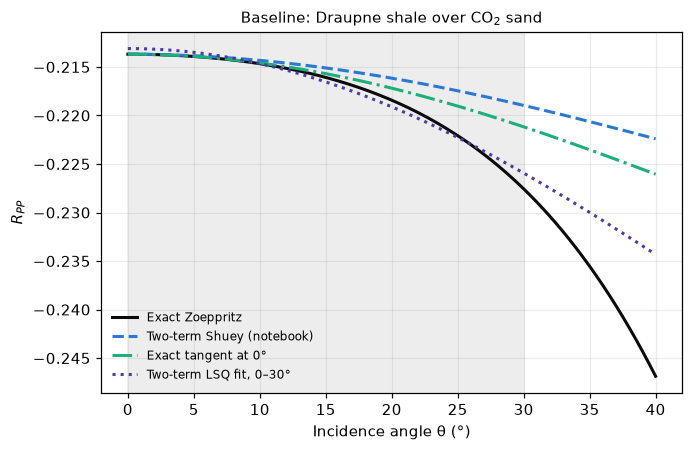

In [11]:
# ---- 9.2  Gradient estimators ------------------------------------------------
def shuey_AB(a1, b1, r1, a2, b2, r2):
    # identical expressions to the sympy objects A_sym, B_sym of section 2 (sigma = sigma(Vp,Vs))
    return A_fn(a1, a2, b1, b2, r1, r2), B_fn(a1, a2, b1, b2, r1, r2)

def ar_gradient(a1, b1, r1, a2, b2, r2):
    # Aki & Richards (1980) linearised gradient (coefficient of sin^2 theta)
    a, b, r = (a1 + a2)/2, (b1 + b2)/2, (r1 + r2)/2
    return 0.5*(a2 - a1)/a - 2*(b/a)**2*((r2 - r1)/r + 2*(b2 - b1)/b)

# Linear-least-squares operators (fixed angle grids -> precomputed pseudo-inverses)
TAN_MAXDEG, TAN_DEG = 20.0, 6            # tangent: degree-6 polynomial in s=sin^2 over 0-20 deg
th_tan = np.deg2rad(np.linspace(0, TAN_MAXDEG, 201)); s_tan = np.sin(th_tan)**2
P_tan  = np.linalg.pinv(np.vander(s_tan, TAN_DEG + 1, increasing=True))   # row 1 -> dR/ds at s=0

def lsq_operator(theta_max_deg, n=301):
    th = np.deg2rad(np.linspace(0, theta_max_deg, n))
    return th, np.linalg.pinv(np.vander(np.sin(th)**2, 2, increasing=True))  # rows: [A, B]
th_lsq, P_lsq = lsq_operator(30.0)

def zoep_B_tan(a1, b1, r1, a2, b2, r2):
    R = rpp_explicit(*(np.asarray(v, float)[..., None] for v in (a1, b1, r1, a2, b2, r2)), th_tan).real
    return R @ P_tan[1]

def zoep_AB_lsq(a1, b1, r1, a2, b2, r2, th=None, P=None):
    th = th_lsq if th is None else th; P = P_lsq if P is None else P
    R = rpp_explicit(*(np.asarray(v, float)[..., None] for v in (a1, b1, r1, a2, b2, r2)), th).real
    return R @ P[0], R @ P[1]

base = (nvp1, nvs1, nrho1, nvp2, nvs2, nrho2)

# convergence of the tangent estimator w.r.t. polynomial degree
print('Tangent-slope convergence (baseline):')
for dg in (4, 6, 8, 10):
    Pd = np.linalg.pinv(np.vander(s_tan, dg + 1, increasing=True))
    print(f'   degree {dg:2d}:  B_Z_tan = {rpp_explicit(*base, th_tan).real @ Pd[1]:+.12f}')

# small-contrast limit: all gradients must converge to Aki-Richards as contrasts -> 0
print('\nSmall-contrast limit (layer 2 = layer 1 * (1-eps, 1-eps/2, 1-eps/3)):')
for eps in (1e-1, 1e-2, 1e-3):
    m = (nvp1, nvs1, nrho1, nvp1*(1 - eps), nvs1*(1 - eps/2), nrho1*(1 - eps/3))
    bt, ba, bs = float(zoep_B_tan(*m)), ar_gradient(*m), float(shuey_AB(*m)[1])
    print(f'   eps={eps:6.0e}: B_Z_tan={bt:+.6e}  B_AR={ba:+.6e}  B_Shuey={bs:+.6e}   rel.dev AR={abs(ba/bt - 1):.1e}  Shuey={abs(bs/bt - 1):.1e}')

B0_shuey = float(shuey_AB(*base)[1]); B0_ar = ar_gradient(*base)
B0_ztan = float(zoep_B_tan(*base)); A0_lsq, B0_zlsq = map(float, zoep_AB_lsq(*base))
print('\nBaseline gradient, shale over CO2 sand:')
print(f'   B_Shuey (notebook)      = {B0_shuey:+.5f}')
print(f'   B_AR   (Aki-Richards)   = {B0_ar:+.5f}')
print(f'   B_Z_tan (exact tangent) = {B0_ztan:+.5f}')
print(f'   B_Z_LSQ (0-30 deg fit)  = {B0_zlsq:+.5f}   (A_LSQ = {A0_lsq:+.5f}, exact A0 = {A0:+.5f})')
print(f'   Shuey / exact-tangent ratio = {B0_shuey/B0_ztan:.3f}')
print('\nBaseline contrasts: dVp/Vp = %+.4f, dVs/Vs = %+.4f, drho/rho = %+.4f' % (
      (nvp2 - nvp1)/((nvp1 + nvp2)/2), (nvs2 - nvs1)/((nvs1 + nvs2)/2), (nrho2 - nrho1)/((nrho1 + nrho2)/2)))

# figure: Rpp(theta) exact vs two-term Shuey and 2-term LSQ fit
thp = np.deg2rad(np.linspace(0, 40, 161)); sp2 = np.sin(thp)**2
Rz  = rpp_explicit(*base, thp).real
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(np.rad2deg(thp), Rz, color='#0b0b0b', lw=2, label='Exact Zoeppritz')
ax.plot(np.rad2deg(thp), A0 + B0_shuey*sp2, color='#2a78d6', lw=2, ls='--', label='Two-term Shuey (notebook)')
ax.plot(np.rad2deg(thp), A0 + B0_ztan*sp2,  color='#1baf7a', lw=2, ls='-.', label='Exact tangent at 0°')
ax.plot(np.rad2deg(thp), A0_lsq + B0_zlsq*sp2, color='#4a3aa7', lw=2, ls=':', label='Two-term LSQ fit, 0–30°')
ax.axvspan(0, 30, color='0.93', zorder=0)
ax.set_xlabel('Incidence angle θ (°)'); ax.set_ylabel('$R_{PP}$')
ax.set_title('Baseline: Draupne shale over CO$_2$ sand', fontsize=10)
ax.grid(alpha=0.25); ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.savefig('fig_rpp_baseline.png', dpi=200, bbox_inches='tight'); plt.show()

**Result 9.2.**
- All three gradient formulas converge to the exact tangent as contrasts → 0 (relative deviation $\propto\varepsilon$). The implementations are therefore consistent.
- At the Smeaheia contrasts ($\Delta V_P/\bar V_P\approx-0.29$) the three estimates differ substantially. The two-term Shuey gradient is about 30 % smaller in magnitude than the exact tangent. It sits *closer to zero*, i.e. closer to the Class III/IV boundary. Aki–Richards errs in the opposite direction.
- The 0–30° least-squares slope is steeper than the tangent because exact $R_{PP}$ curves downward in $\sin^2\theta$ (third-term / curvature contribution). A two-term inversion therefore reports a gradient that depends on the aperture (quantified in §9.4).

### 9.3 Reproducing the Shuey threshold (the "~4.4 %" statement)

In [12]:
# ---- 9.3  Threshold search machinery ---------------------------------------
from scipy.optimize import brentq, minimize_scalar

def B_estimator(est, r1, r2):
    # gradient for relative Vp errors r1 (caprock) and r2 (reservoir); Vs, rho unperturbed
    m = (nvp1*(1 + r1), nvs1, nrho1, nvp2*(1 + r2), nvs2, nrho2)
    if est == 'shuey': return float(shuey_AB(*m)[1])
    if est == 'ar':    return ar_gradient(*m)
    if est == 'ztan':  return float(zoep_B_tan(*m))
    if est == 'zlsq':  return float(zoep_AB_lsq(*m)[1])
    raise ValueError(est)

def threshold_along(est, phi_deg, rmax=0.10, n=201):
    # smallest |r| <= rmax with B(|r| cos phi, |r| sin phi) = 0 ; nan if none
    ph = np.deg2rad(phi_deg); f = lambda r: B_estimator(est, r*np.cos(ph), r*np.sin(ph))
    rs = np.linspace(0, rmax, n); v = np.array([f(r) for r in rs])
    i = np.where(np.sign(v[1:]) != np.sign(v[:-1]))[0]
    return brentq(f, rs[i[0]], rs[i[0] + 1], xtol=1e-12) if i.size else np.nan

def min_threshold(est):
    # minimum radius of the B=0 contour over all error directions (coarse 1 deg scan + refinement)
    phis = np.arange(0, 360, 1.0)
    t = np.array([threshold_along(est, p) for p in phis])
    k = np.nanargmin(t)
    res = minimize_scalar(lambda p: threshold_along(est, p), bounds=(phis[k] - 1, phis[k] + 1),
                          method='bounded', options={'xatol': 1e-6})
    return res.fun, res.x

r135_shuey = threshold_along('shuey', 135.0)
rmin_shuey, phimin_shuey = min_threshold('shuey')
d_shuey = rmin_shuey*(np.cos(np.deg2rad(phimin_shuey)) - np.sin(np.deg2rad(phimin_shuey)))
print('Two-term Shuey (the notebook engine, sigma = sigma(Vp)):')
print(f'   B = 0 along phi = 135 deg spoke : |r| = {100*r135_shuey:.3f} %   (r1-r2 = {-100*np.sqrt(2)*r135_shuey:+.3f} %)')
print(f'   minimum |r| over all phi        : |r| = {100*rmin_shuey:.3f} %  at phi = {phimin_shuey:.2f} deg'
      f'   (r1 = {100*rmin_shuey*np.cos(np.deg2rad(phimin_shuey)):+.3f} %, r2 = {100*rmin_shuey*np.sin(np.deg2rad(phimin_shuey)):+.3f} %, r1-r2 = {100*d_shuey:+.3f} %)')
print('\nNotebook text (section 7, reading 5): "|r| ~ 4.4 % along the phi = 135 deg spoke"')
print(f'   -> 4.4 % reproduces as the MINIMUM-radius threshold ({100*rmin_shuey:.2f} %, phi = {phimin_shuey:.1f} deg),')
print(f'      NOT the 135 deg spoke ({100*r135_shuey:.2f} %).  Flagged; both values are carried forward explicitly.')

# endpoints of the section-7 spokes at |r| = 10 % (Shuey engine) -- checks the section-7 text
print('\nShuey (A, B) at |r| = 10 % along the labelled spokes of section 7:')
for p in (0, 45, 90, 135, 180, 225, 270, 315):
    c, s_ = np.cos(np.deg2rad(p)), np.sin(np.deg2rad(p))
    Ae, Be = shuey_AB(nvp1*(1 + .1*c), nvs1, nrho1, nvp2*(1 + .1*s_), nvs2, nrho2)
    print(f'   phi = {p:3d} deg:  A = {Ae:+.4f}   B = {Be:+.4f}')
print('   (section 7 text states B ~ -0.055 at the 315 deg endpoint; the computed value is printed above)')

Two-term Shuey (the notebook engine, sigma = sigma(Vp)):
   B = 0 along phi = 135 deg spoke : |r| = 4.752 %   (r1-r2 = -6.721 %)
   minimum |r| over all phi        : |r| = 4.444 %  at phi = 156.60 deg   (r1 = -4.079 %, r2 = +1.765 %, r1-r2 = -5.844 %)

Notebook text (section 7, reading 5): "|r| ~ 4.4 % along the phi = 135 deg spoke"
   -> 4.4 % reproduces as the MINIMUM-radius threshold (4.44 %, phi = 156.6 deg),
      NOT the 135 deg spoke (4.75 %).  Flagged; both values are carried forward explicitly.

Shuey (A, B) at |r| = 10 % along the labelled spokes of section 7:
   phi =   0 deg:  A = -0.2587   B = -0.0554
   phi =  45 deg:  A = -0.2137   B = -0.0392
   phi =  90 deg:  A = -0.1678   B = +0.0003
   phi = 135 deg:  A = -0.1452   B = +0.0304
   phi = 180 deg:  A = -0.1629   B = +0.0270
   phi = 225 deg:  A = -0.2137   B = +0.0033
   phi = 270 deg:  A = -0.2634   B = -0.0104
   phi = 315 deg:  A = -0.2802   B = -0.0351
   (section 7 text states B ~ -0.055 at the 315 deg endpoint; t

### 9.4 Exact-Zoeppritz thresholds

In [13]:
# ---- 9.4  Thresholds for all estimators --------------------------------------
ests = {'shuey': 'Two-term Shuey', 'ar': 'Aki-Richards', 'ztan': 'Zoeppritz tangent', 'zlsq': 'Zoeppritz LSQ 0-30'}
spokes = [0, 45, 90, 135, 180, 225, 270, 315]
thr = {e: {p: threshold_along(e, p) for p in spokes} for e in ests}
thr_min = {e: min_threshold(e) for e in ests}

print('B = 0 threshold |r| (%) along each error direction phi (nan = no crossing within 10 %):')
print(f'{"phi":>5s}  ' + ''.join(f'{ests[e]:>21s}' for e in ests))
for p in spokes:
    print(f'{p:5d}  ' + ''.join(f'{100*thr[e][p]:21.3f}' for e in ests))
print(f'{"min":>5s}  ' + ''.join(f'{100*thr_min[e][0]:13.3f} @{thr_min[e][1]:5.1f}°' for e in ests))

r135 = {e: thr[e][135] for e in ests}
print('\nAttribution along phi = 135 deg (the direction named in the notebook):')
print(f'   Shuey {100*r135["shuey"]:.3f} %  ->  exact tangent {100*r135["ztan"]:.3f} %  :  '
      f'Shuey underestimates the required error by {100*(r135["ztan"] - r135["shuey"]):.3f} pp '
      f'({100*(r135["ztan"] - r135["shuey"])/r135["ztan"]:.1f} % of the exact value)')
print('Attribution at the minimum-radius point:')
print(f'   Shuey {100*thr_min["shuey"][0]:.3f} %  ->  exact tangent {100*thr_min["ztan"][0]:.3f} %  :  '
      f'difference {100*(thr_min["ztan"][0] - thr_min["shuey"][0]):.3f} pp '
      f'({100*(thr_min["ztan"][0] - thr_min["shuey"][0])/thr_min["ztan"][0]:.1f} % of the exact value)')

# aperture sensitivity of the practical (LSQ) threshold
print('\nAperture sensitivity of the two-term LSQ fit to exact Zoeppritz:')
ap_res = {}
for tmax in (20, 25, 30, 35, 40):
    thA, PA = lsq_operator(float(tmax))
    fB = lambda r1, r2, thA=thA, PA=PA: float(zoep_AB_lsq(nvp1*(1 + r1), nvs1, nrho1, nvp2*(1 + r2), nvs2, nrho2, thA, PA)[1])
    ph = np.deg2rad(135.0); rs = np.linspace(0, 0.10, 201)
    v = np.array([fB(r*np.cos(ph), r*np.sin(ph)) for r in rs]); i = np.where(np.sign(v[1:]) != np.sign(v[:-1]))[0]
    r0 = brentq(lambda r: fB(r*np.cos(ph), r*np.sin(ph)), rs[i[0]], rs[i[0] + 1], xtol=1e-12) if i.size else np.nan
    ap_res[tmax] = (fB(0, 0), r0)
    print(f'   0-{tmax:2d} deg: B0 = {ap_res[tmax][0]:+.5f}   threshold along 135 deg = {100*r0:6.3f} %')

B = 0 threshold |r| (%) along each error direction phi (nan = no crossing within 10 %):
  phi         Two-term Shuey         Aki-Richards    Zoeppritz tangent   Zoeppritz LSQ 0-30
    0                    nan                  nan                  nan                  nan
   45                    nan                  nan                  nan                  nan
   90                  9.900                  nan                  nan                  nan
  135                  4.752                6.206                5.755                8.455
  180                  4.802                7.064                6.484                9.628
  225                  8.826                  nan                  nan                  nan
  270                    nan                  nan                  nan                  nan
  315                    nan                  nan                  nan                  nan
  min          4.444 @156.6°        6.035 @148.5°        5.580 @149.2°        8.225 

### 9.5 $B=0$ contours in the error plane

Vectorised maps agree with scalar estimators (<1e-12).
   fraction of +/-10 % square misclassified (B>0),       Two-term Shuey: 29.55 %
   fraction of +/-10 % square misclassified (B>0),         Aki-Richards: 16.95 %
   fraction of +/-10 % square misclassified (B>0),    Zoeppritz tangent: 19.05 %
   fraction of +/-10 % square misclassified (B>0),   Zoeppritz LSQ 0-30:  8.75 %


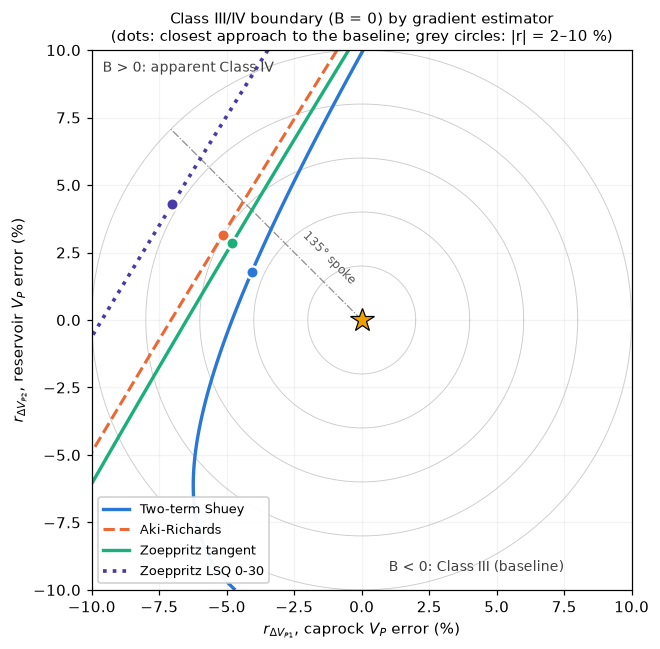

In [14]:
# ---- 9.5  Error-plane map of the Class III/IV boundary for each estimator ----
g = np.linspace(-0.10, 0.10, 161)
R1, R2 = np.meshgrid(g, g, indexing='ij')
V1, V2 = nvp1*(1 + R1), nvp2*(1 + R2)
Bmaps = {
    'shuey': B_fn(V1, V2, nvs1, nvs2, nrho1, nrho2),
    'ar':    ar_gradient(V1, nvs1, nrho1, V2, nvs2, nrho2),
    'ztan':  zoep_B_tan(V1, nvs1, nrho1, V2, nvs2, nrho2),
    'zlsq':  zoep_AB_lsq(V1, nvs1, nrho1, V2, nvs2, nrho2)[1],
}
# spot-check vectorised maps against the scalar estimators used for thresholds
for e in ests:
    assert abs(Bmaps[e][40, 120] - B_estimator(e, g[40], g[120])) < 1e-12, e
print('Vectorised maps agree with scalar estimators (<1e-12).')
for e in ests:
    print(f'   fraction of +/-10 % square misclassified (B>0), {ests[e]:>20s}: {100*np.mean(Bmaps[e] > 0):5.2f} %')

styles = {'shuey': ('#2a78d6', '-', 2.2), 'ar': ('#eb6834', '--', 2.0),
          'ztan': ('#1baf7a', '-', 2.2), 'zlsq': ('#4a3aa7', ':', 2.4)}
fig, ax = plt.subplots(figsize=(6.6, 6.0))
for e, (col, ls, lw) in styles.items():
    cs = ax.contour(100*R1, 100*R2, Bmaps[e], levels=[0], colors=[col], linestyles=[ls], linewidths=lw)
    ax.plot([], [], color=col, ls=ls, lw=lw, label=ests[e])
    rm, pm = thr_min[e]
    ax.plot(100*rm*np.cos(np.deg2rad(pm)), 100*rm*np.sin(np.deg2rad(pm)), 'o', ms=8, mfc=col, mec='white', mew=1.5, zorder=5)
circ = np.linspace(0, 2*np.pi, 361)
for rr in (2, 4, 6, 8, 10):
    ax.plot(rr*np.cos(circ), rr*np.sin(circ), color='0.8', lw=0.6, zorder=0)
ax.plot([0, -10/np.sqrt(2)], [0, 10/np.sqrt(2)], color='0.55', lw=0.8, ls='-.', zorder=1)
ax.text(-1.2, 2.3, '135° spoke', color='0.35', fontsize=8, rotation=-45, ha='center', va='center')
ax.plot(0, 0, marker='*', color='#eda100', ms=16, mec='k', mew=0.8, zorder=6)
ax.text(-9.6, 9.2, 'B > 0: apparent Class IV', fontsize=9, color='0.25')
ax.text(1.0, -9.3, 'B < 0: Class III (baseline)', fontsize=9, color='0.25')
ax.set_xlim(-10, 10); ax.set_ylim(-10, 10); ax.set_aspect('equal')
ax.set_xlabel(r'$r_{\Delta V_{P1}}$, caprock $V_P$ error (%)'); ax.set_ylabel(r'$r_{\Delta V_{P2}}$, reservoir $V_P$ error (%)')
ax.set_title('Class III/IV boundary (B = 0) by gradient estimator\n(dots: closest approach to the baseline; grey circles: |r| = 2–10 %)', fontsize=9.5)
ax.legend(loc='lower left', fontsize=8.5, frameon=True, framealpha=0.95)
ax.grid(alpha=0.15)
plt.tight_layout(); plt.savefig('fig_B0_contours.png', dpi=200, bbox_inches='tight'); plt.show()

### 9.6 Poisson's-ratio dependence: fixed-$\sigma$ versus total sensitivity

In §2 `spr` and `dpr` enter `sp.diff` as independent symbols, so $k_B$ is $\partial B/\partial V_{Pi}$ at *fixed* $\sigma_1,\sigma_2$. Physically $\sigma_i=\sigma(V_{Pi},V_{Si})$, and the nonlinear curves of §4–§7 (`B_fn`) include that dependence. The cell below computes the total derivative and tests the "common-mode cancellation" statement.

In [15]:
# ---- 9.6  Fixed-sigma (notebook k_B) vs total derivative -----------------------
B_total = B_sym.subs({spr: spr_expr, dpr: dpr_expr})
sub0 = {vp1: nvp1, vp2: nvp2, vs1: nvs1, vs2: nvs2, rho1: nrho1, rho2: nrho2}
fixed = {**sub0, spr: float(spr_expr.subs(sub0)), dpr: float(dpr_expr.subs(sub0))}
g_fix = [float((sp.diff(B_sym, v)*v).subs(fixed)) for v in (vp1, vp2)]   # dB/d(ln Vp_i), sigma fixed
g_tot = [float((sp.diff(B_total, v)*v).subs(sub0)) for v in (vp1, vp2)]  # dB/d(ln Vp_i), total
print('dB / d(ln Vp_i) at the baseline:')
print(f'   sigma fixed (notebook): caprock {g_fix[0]:+.4f}   reservoir {g_fix[1]:+.4f}   sum {g_fix[0] + g_fix[1]:+.2e}')
print(f'   total (sigma = f(Vp))  : caprock {g_tot[0]:+.4f}   reservoir {g_tot[1]:+.4f}   sum {g_tot[0] + g_tot[1]:+.4f}')
print(f'   k_B check: g_fix[0]/B0 = {g_fix[0]/B0:+.3f}  (notebook k_B = {kB:+.3f})')
print(f'   total-derivative analogue: caprock {g_tot[0]/B0:+.3f}, reservoir {g_tot[1]/B0:+.3f}  (relative to B0)')

# first-order (linearised-in-r) threshold along 135 deg
u = np.array([np.cos(np.deg2rad(135)), np.sin(np.deg2rad(135))])
slope_fix = g_fix[0]*u[0] + g_fix[1]*u[1]; slope_tot = g_tot[0]*u[0] + g_tot[1]*u[1]
print('\nFirst-order threshold along 135 deg, |r| = -B0 / (dB/d|r|):')
print(f'   sigma fixed: dB/d|r| = {slope_fix:+.4f} -> ' + ('no crossing (B moves deeper into Class III)' if slope_fix*B0 > 0 else f'{-100*B0/slope_fix:.3f} %'))
print(f'   total      : dB/d|r| = {slope_tot:+.4f} -> {-100*B0/slope_tot:.3f} %   (nonlinear Shuey: {100*r135_shuey:.3f} %)')

# common-mode test at 10 %
print('\nCommon-mode test, r1 = r2 = +/-10 %:')
for e in ests:
    print(f'   {ests[e]:>20s}: B(0) = {B_estimator(e, 0, 0):+.5f}   B(+10,+10) = {B_estimator(e, .1, .1):+.5f}   B(-10,-10) = {B_estimator(e, -.1, -.1):+.5f}')
print(f'   A (all, exact)      : A(0) = {A0:+.5f}   A(+10,+10) = {A_fn(1.1*nvp1, 1.1*nvp2, nvs1, nvs2, nrho1, nrho2):+.5f}   (A is invariant to common-mode scaling)')

dB / d(ln Vp_i) at the baseline:
   sigma fixed (notebook): caprock +0.6603   reservoir -0.6603   sum -3.33e-16
   total (sigma = f(Vp))  : caprock -0.4050   reservoir +0.1114   sum -0.2936
   k_B check: g_fix[0]/B0 = -31.277  (notebook k_B = -31.277)
   total-derivative analogue: caprock +19.183, reservoir -5.277  (relative to B0)

First-order threshold along 135 deg, |r| = -B0 / (dB/d|r|):
   sigma fixed: dB/d|r| = -0.9339 -> no crossing (B moves deeper into Class III)
   total      : dB/d|r| = +0.3651 -> 5.782 %   (nonlinear Shuey: 4.752 %)

Common-mode test, r1 = r2 = +/-10 %:
         Two-term Shuey: B(0) = -0.02111   B(+10,+10) = -0.04539   B(-10,-10) = +0.01618
           Aki-Richards: B(0) = -0.04450   B(+10,+10) = -0.06157   B(-10,-10) = -0.02143
      Zoeppritz tangent: B(0) = -0.02994   B(+10,+10) = -0.04331   B(-10,-10) = -0.01169
     Zoeppritz LSQ 0-30: B(0) = -0.05133   B(+10,+10) = -0.06458   B(-10,-10) = -0.03324
   A (all, exact)      : A(0) = -0.21369   A(+10,+10) = 

### 9.7 Context: realistic $V_P$ uncertainty and model consistency (Hema et al., 2027)

Numbers transcribed from Hema et al. (2027, *Geoenergy Sci. Eng.* 268, 214769), Tables 1, 2 and 12 (Sognefjord Fm., wells 32/4-1 and 32/2-1). The paper is a scanned PDF, so these values were typed from page images and should be proof-read against the original tables.

In [16]:
# ---- 9.7  Hema et al. (2027) context ----------------------------------------------
hema = {'Vp_mean_32_4_1': 2975.4836, 'Vp_min_32_4_1': 2748.2744, 'Vp_std_32_4_1': 399.3568,   # Table 1
        'Vp_mean_32_2_1': 2721.751,  'Vp_min_32_2_1': 2436.4805, 'Vp_std_32_2_1': 358.2966,   # Table 2
        'rmse_MAR_val': 380.91, 'rmse_PNN_val': 461.3}                                        # Table 12 (m/s)
for k in ('rmse_MAR_val', 'rmse_PNN_val'):
    for w in ('32_4_1', '32_2_1'):
        print(f'   {k:13s} / mean Sognefjord Vp ({w.replace("_", "/", 1).replace("_", "-")}) = {100*hema[k]/hema["Vp_mean_" + w]:5.2f} %')
print(f'\nModel brine-sand Vp = {nvp2_brine:.0f} m/s vs Sognefjord log minima {hema["Vp_min_32_2_1"]:.0f} (32/2-1), '
      f'{hema["Vp_min_32_4_1"]:.0f} (32/4-1) m/s; vs means: {100*(nvp2_brine/hema["Vp_mean_32_2_1"] - 1):+.1f} %, {100*(nvp2_brine/hema["Vp_mean_32_4_1"] - 1):+.1f} %')
# Gassmann consistency of Vs (shear modulus unchanged by fluid)
vs_gassmann = nvs2_brine*np.sqrt(nrho2_brine/nrho2_co2)
print(f'Gassmann Vs_CO2 = Vs_brine*sqrt(rho_brine/rho_CO2) = {vs_gassmann:.1f} m/s  (model: {nvs2_co2:.0f} m/s, diff {nvs2_co2 - vs_gassmann:+.1f} m/s)')

   rmse_MAR_val  / mean Sognefjord Vp (32/4-1) = 12.80 %
   rmse_MAR_val  / mean Sognefjord Vp (32/2-1) = 14.00 %
   rmse_PNN_val  / mean Sognefjord Vp (32/4-1) = 15.50 %
   rmse_PNN_val  / mean Sognefjord Vp (32/2-1) = 16.95 %

Model brine-sand Vp = 2200 m/s vs Sognefjord log minima 2436 (32/2-1), 2748 (32/4-1) m/s; vs means: -19.2 %, -26.1 %
Gassmann Vs_CO2 = Vs_brine*sqrt(rho_brine/rho_CO2) = 1183.5 m/s  (model: 1180 m/s, diff -3.5 m/s)


### 9.8 Consolidated numbers for the manuscript

Every quantitative statement in `chapter1_manuscript_draft.md` is taken from the printout below or from the cells it summarises.

In [17]:
# ---- 9.8  Consolidated numbers ----------------------------------------------------
import json
out = {
 'A0': A0, 'B0_shuey': B0, 'C0': C0, 'A0_brine': A0_br, 'B0_brine': B0_br, 'kA': kA, 'kB_fixed_sigma': kB, 'kC': kC,
 'GI0': GI0, 'GI_min': float(GI_grid.min()), 'GI_max': float(GI_grid.max()),
 'A_max_over_grid': float(A_grid.max()),
 'B0_ar': B0_ar, 'B0_ztan': B0_ztan, 'B0_zlsq30': B0_zlsq, 'A0_lsq30': A0_lsq,
 'thr135': {e: r135[e] for e in ests}, 'thr_min': {e: list(thr_min[e]) for e in ests},
 'thr_spokes': {e: {str(p): thr[e][p] for p in spokes} for e in ests},
 'lsq_aperture': {str(k): list(v) for k, v in ap_res.items()},
 'misclassified_fraction': {e: float(np.mean(Bmaps[e] > 0)) for e in ests},
 'dB_dlnVp_fixed': g_fix, 'dB_dlnVp_total': g_tot, 'first_order_thr135_total': float(-B0/slope_tot),
}
json.dump(out, open('chapter1_numbers.json', 'w'), indent=1, default=float)
print(json.dumps(out, indent=1, default=lambda x: float(x)))

{
 "A0": -0.21368624919302776,
 "B0_shuey": -0.021112569997731756,
 "C0": -0.14285714285714285,
 "A0_brine": -0.12730627306273062,
 "B0_brine": 0.002273553101357642,
 "kA": 2.2330360294820357,
 "kB_fixed_sigma": -31.276929292556343,
 "kC": 3.4285714285714284,
 "GI0": 0.00451146589364055,
 "GI_min": -0.0067637798243417166,
 "GI_max": 0.014441502090850157,
 "A_max_over_grid": -0.11616861270532357,
 "B0_ar": -0.0445042979500303,
 "B0_ztan": -0.02993656597134664,
 "B0_zlsq30": -0.05132698424341678,
 "A0_lsq30": -0.2131049820836364,
 "thr135": {
  "shuey": 0.047523024010877844,
  "ar": 0.0620610970539972,
  "ztan": 0.05755263418111218,
  "zlsq": 0.08454948719175993
 },
 "thr_min": {
  "shuey": [
   0.04444181204463587,
   156.59945901872294
  ],
  "ar": [
   0.06034766979380846,
   148.54570830086777
  ],
  "ztan": [
   0.055800064233791115,
   149.23612591337297
  ],
  "zlsq": [
   0.08225109661480356,
   148.4681260886955
  ]
 },
 "thr_spokes": {
  "shuey": {
   "0": NaN,
   "45": NaN,
  

### 9.9 Cross-check conclusions

1. **The exact-Zoeppritz check confirms that Class III → IV misclassification is physical**, but it needs larger velocity errors than Shuey predicts. With the exact tangent gradient, the threshold along $\phi=135°$ rises from 4.75 % (Shuey) to 5.76 % (+1.00 pp; Shuey is 17.4 % low). The minimum-radius threshold rises from 4.44 % to 5.58 % (+1.14 pp; Shuey is 20.4 % low). The *existence* of the crossing within ±10 % is physical; its *location* is biased low by the two-term approximation.
2. **The artifact comes from the baseline, not from the error sensitivity.** Shuey places $B_0$ about 30 % closer to zero than the exact tangent ($-0.0211$ vs $-0.0299$), so less error is needed to reach $B=0$.
3. **The practical threshold depends on the aperture.** A two-term fit over 0–30° of exact $R_{PP}$ gives $B_0=-0.051$ and pushes the 135° threshold to 8.45 %. Over 0–40° no crossing occurs within ±10 %. A "Class" assigned from a two-term fit is therefore aperture-dependent for this interface.
4. **Shuey-only crossings.** For reservoir-only errors ($\phi=90°$) and common-mode errors ($\phi=225°$) Shuey crosses $B=0$ within 10 %. Neither Zoeppritz estimator does, so these crossings are artifacts of the approximation.
5. **Common-mode errors do not cancel in $B$**, in Shuey *or* in exact Zoeppritz. Scaling $V_P$ with $V_S$ fixed changes $V_S/V_P$ and hence $\sigma$; exact $R_{PP}$ is invariant only when all velocities scale together. The notebook's $k_B=-31.28$ is a fixed-$\sigma$ partial derivative. With $\sigma(V_P)$ the first-order sensitivity of $B$ to a caprock $V_P$ error even changes sign (§9.6).

## 10. Publication figures and Appendix-B check

The cells below redraw the figures for the manuscript (`paper/figures/`) from arrays already computed above. The data are unchanged, but the presentation differs: no embedded titles (captions carry them), panel letters, a colour-vision-deficiency-checked palette, and corrected spoke labels. The original §7 figure labels the common-mode spokes "errors cancel", which §9.6 shows is false for $B$. The original figures above are left untouched for traceability.

In [18]:
# ---- 10.1  Appendix-B check: chain rule for the total sensitivity of B -----------------
s1, s2 = sp.symbols('sigma1 sigma2')
B_s12 = B_sym.subs({spr: s1 + s2, dpr: s2 - s1})             # Shuey B written in (sigma1, sigma2)
dsig_dlnvp = lambda VP, VS: VP**2*VS**2/(VP**2 - VS**2)**2  # d sigma / d ln Vp  (Appendix B, eq. B-2)
sig = {s1: float(pr1.subs(sub0)), s2: float(pr2.subs(sub0))}
chain = []
for v, s_i, (VP, VS) in ((vp1, s1, (nvp1, nvs1)), (vp2, s2, (nvp2, nvs2))):
    partial = float((sp.diff(B_s12, v)*v).subs({**sub0, **sig}))
    dB_dsig = float(sp.diff(B_s12, s_i).subs({**sub0, **sig}))
    chain.append(partial + dB_dsig*dsig_dlnvp(VP, VS))
    print(f'{str(v)}: dB/dlnVp|sigma = {partial:+.4f}  dB/dsigma = {dB_dsig:+.4f}  dsigma/dlnVp = {dsig_dlnvp(VP, VS):+.4f}'
          f'  -> total = {chain[-1]:+.4f}')
# symbolic check of eq. B-2 and numerical check of eq. B-1 against section 9.6
VPs, VSs = sp.symbols('V_P V_S', positive=True)
sig_expr = (VPs**2 - 2*VSs**2)/(2*(VPs**2 - VSs**2))
assert sp.simplify(sp.diff(sig_expr, VPs)*VPs - VPs**2*VSs**2/(VPs**2 - VSs**2)**2) == 0
assert np.allclose(chain, g_tot, rtol=0, atol=1e-12)
print(f'sigma1 = {sig[s1]:.4f}, sigma2 = {sig[s2]:.4f}')
print('Chain rule (eq. B-1, B-2) reproduces the section-9.6 total derivatives to 1e-12: PASSED')

vp1: dB/dlnVp|sigma = +0.6603  dB/dsigma = -3.0974  dsigma/dlnVp = +0.3439  -> total = -0.4050
vp2: dB/dlnVp|sigma = -0.6603  dB/dsigma = +0.8467  dsigma/dlnVp = +0.9115  -> total = +0.1114
sigma1 = 0.3647, sigma2 = 0.2111
Chain rule (eq. B-1, B-2) reproduces the section-9.6 total derivatives to 1e-12: PASSED


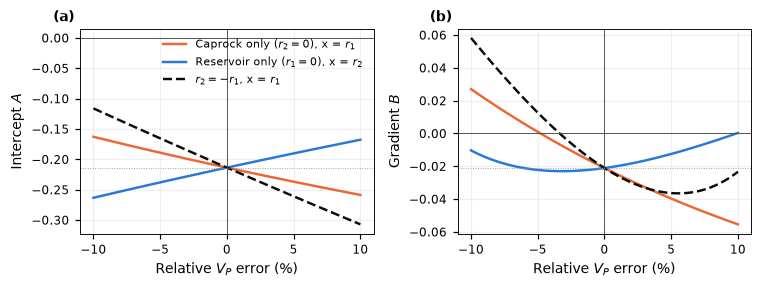

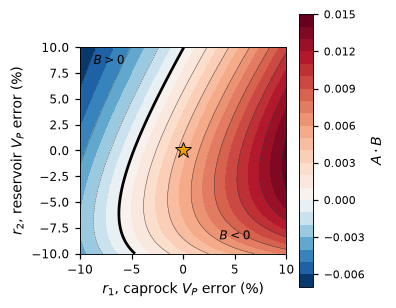

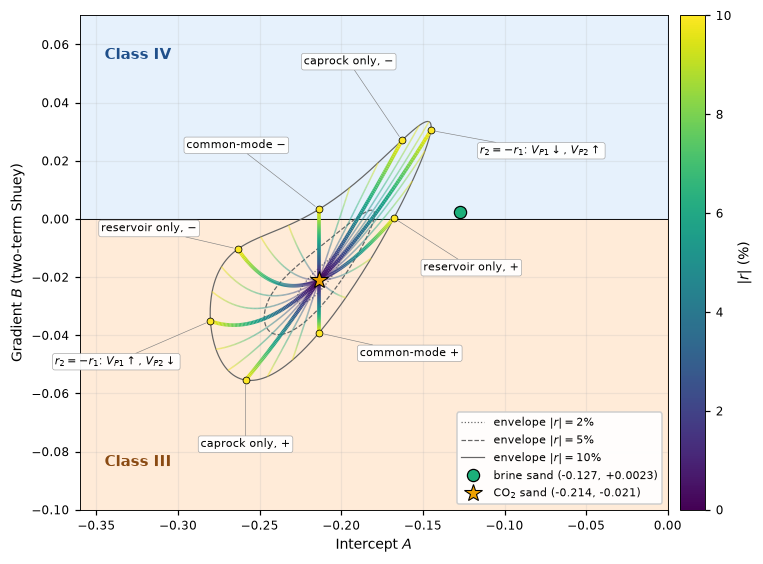

In [19]:
# ---- 10.2  Publication figures 1-3 (sections 4, 5, 7 data) ----------------------------
import os
from matplotlib.colors import TwoSlopeNorm
os.makedirs('paper/figures', exist_ok=True)
pub = {'font.size': 9, 'axes.labelsize': 9, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
       'legend.fontsize': 7.5, 'axes.linewidth': 0.6, 'lines.linewidth': 1.6}
C_CAP, C_RES, C_DIF = '#eb6834', '#2a78d6', '#0b0b0b'   # validated categorical slots (orange, blue, ink)
def save(fig, name):
    fig.savefig(f'paper/figures/{name}.pdf', bbox_inches='tight')
    fig.savefig(f'paper/figures/{name}.png', dpi=200, bbox_inches='tight')

with plt.rc_context(pub):
    # Figure 1 -- A and B slices (section 4 arrays)
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.7))
    for ax, (Yc, Yr, Yd, Y0, lab) in zip(axes, [(A_cap, A_res, A_dif, A0, 'Intercept $A$'),
                                                 (B_cap, B_res, B_dif, B0, 'Gradient $B$')]):
        ax.plot(errs_pct, Yc, color=C_CAP, label='Caprock only ($r_2=0$), x = $r_1$')
        ax.plot(errs_pct, Yr, color=C_RES, label='Reservoir only ($r_1=0$), x = $r_2$')
        ax.plot(errs_pct, Yd, color=C_DIF, ls='--', label='$r_2=-r_1$, x = $r_1$')
        ax.axhline(0, color='0.3', lw=0.6); ax.axvline(0, color='0.3', lw=0.6)
        ax.axhline(Y0, color='0.6', lw=0.6, ls=':')
        ax.set_xlabel('Relative $V_P$ error (%)'); ax.set_ylabel(lab); ax.grid(alpha=0.2)
    axes[0].legend(loc='upper right', frameon=False)
    for ax, t in zip(axes, ('(a)', '(b)')):
        ax.text(-0.02, 1.02, t, transform=ax.transAxes, va='bottom', ha='right', fontweight='bold')
    plt.tight_layout(); save(fig, 'fig01_AB_slices'); plt.show()

    # Figure 2 -- A*B over the error plane (section 5 arrays)
    fig, ax = plt.subplots(figsize=(3.6, 3.1))
    nrm = TwoSlopeNorm(vcenter=0.0, vmin=GI_grid.min(), vmax=GI_grid.max())
    cf = ax.contourf(RDV1*100, RDV2*100, GI_grid, levels=24, cmap='RdBu_r', norm=nrm)
    ax.contour(RDV1*100, RDV2*100, GI_grid, levels=10, colors='0.25', linewidths=0.3)
    ax.contour(RDV1*100, RDV2*100, B_grid, levels=[0], colors='k', linewidths=1.8)
    ax.plot(0, 0, marker='*', color='#eda100', ms=11, mec='k', mew=0.6)
    ax.text(-8.7, 8.3, '$B>0$', fontsize=8); ax.text(3.5, -8.7, '$B<0$', fontsize=8)
    cb = fig.colorbar(cf, ax=ax); cb.set_label('$A\\cdot B$'); cb.ax.tick_params(labelsize=7)
    ax.set_xlabel('$r_1$, caprock $V_P$ error (%)'); ax.set_ylabel('$r_2$, reservoir $V_P$ error (%)')
    ax.set_aspect('equal'); plt.tight_layout(); save(fig, 'fig02_GI_map'); plt.show()

    # Figure 3 -- radial spokes in the A-B crossplot (section 7 functions), corrected labels
    pub_labels = {0: 'caprock only, $+$', 45: 'common-mode $+$', 90: 'reservoir only, $+$',
                  135: '$r_2=-r_1$: $V_{P1}\\downarrow$, $V_{P2}\\uparrow$', 180: 'caprock only, $-$',
                  225: 'common-mode $-$', 270: 'reservoir only, $-$',
                  315: '$r_2=-r_1$: $V_{P1}\\uparrow$, $V_{P2}\\downarrow$'}
    fig, ax = plt.subplots(figsize=(7.0, 5.2))
    ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
    ax.fill_between([-0.4, 0], 0, -0.12, color='#ffd9b3', alpha=0.5, zorder=0)
    ax.fill_between([-0.4, 0], 0,  0.10, color='#d6e8fb', alpha=0.6, zorder=0)
    ax.text(-0.345, -0.085, 'Class III', fontsize=10, fontweight='bold', color='#8a4a12')
    ax.text(-0.345,  0.055, 'Class IV',  fontsize=10, fontweight='bold', color='#1f4f8a')
    for r, ls in zip([0.02, 0.05, 0.10], [':', '--', '-']):
        rd1 = r*np.cos(phi_dense); rd2 = r*np.sin(phi_dense)
        ax.plot(A_fn(nvp1*(1 + rd1), nvp2*(1 + rd2), nvs1, nvs2, nrho1, nrho2),
                B_fn(nvp1*(1 + rd1), nvp2*(1 + rd2), nvs1, nvs2, nrho1, nrho2),
                ls, color='0.4', lw=0.8, zorder=2, label=f'envelope $|r|={100*r:.0f}$%')
    for d in phi_intermediate_deg: draw_spoke(np.deg2rad(d), lw=1.0, alpha=0.5)
    for d in phi_labelled_deg:
        Ae, Be = draw_spoke(np.deg2rad(d), lw=2.4, alpha=1.0)
        ax.plot(Ae, Be, 'o', mfc=cmap(norm(10)), mec='k', mew=0.5, ms=4.5, zorder=5)
        dx, dy, ha, va = spoke_offsets[d]
        ax.annotate(pub_labels[d], xy=(Ae, Be), xytext=(Ae + dx, Be + dy), fontsize=7.5, ha=ha, va=va,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.6', lw=0.4, alpha=0.95),
                    arrowprops=dict(arrowstyle='-', color='0.5', lw=0.4, shrinkA=0, shrinkB=3), zorder=6)
    ax.plot(A0_br, B0_br, 'o', ms=8, mfc='#1baf7a', mec='k', mew=0.8, zorder=7,
            label=f'brine sand ({A0_br:+.3f}, {B0_br:+.4f})')
    ax.plot(A0, B0, '*', ms=12, mfc='#eda100', mec='k', mew=0.7, zorder=8,
            label=f'CO$_2$ sand ({A0:+.3f}, {B0:+.3f})')
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02); cb.set_label('$|r|$ (%)')
    ax.set_xlim(-0.36, 0.0); ax.set_ylim(-0.10, 0.07)
    ax.set_xlabel('Intercept $A$'); ax.set_ylabel('Gradient $B$ (two-term Shuey)')
    ax.legend(loc='lower right', frameon=True, framealpha=0.95); ax.grid(alpha=0.2)
    plt.tight_layout(); save(fig, 'fig03_AB_spokes'); plt.show()

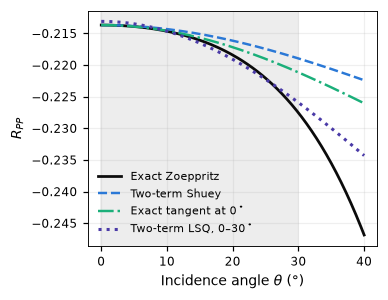

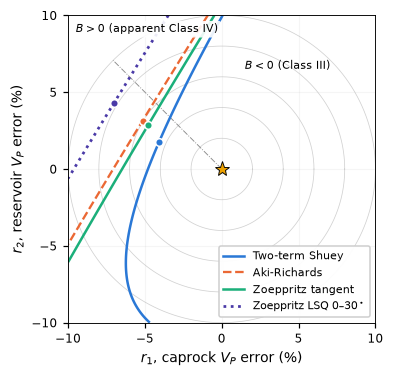

['fig01_AB_slices.pdf', 'fig01_AB_slices.png', 'fig02_GI_map.pdf', 'fig02_GI_map.png', 'fig03_AB_spokes.pdf', 'fig03_AB_spokes.png', 'fig04_rpp_baseline.pdf', 'fig04_rpp_baseline.png', 'fig05_B0_contours.pdf', 'fig05_B0_contours.png']


In [20]:
# ---- 10.3  Publication figures 4-5 (section 9 arrays) ---------------------------------
with plt.rc_context(pub):
    # Figure 4 -- exact Rpp vs two-term curves at the baseline
    fig, ax = plt.subplots(figsize=(3.6, 2.8))
    ax.axvspan(0, 30, color='0.93', zorder=0)
    ax.plot(np.rad2deg(thp), Rz, color='#0b0b0b', lw=1.8, label='Exact Zoeppritz')
    ax.plot(np.rad2deg(thp), A0 + B0_shuey*sp2, color='#2a78d6', ls='--', label='Two-term Shuey')
    ax.plot(np.rad2deg(thp), A0 + B0_ztan*sp2, color='#1baf7a', ls='-.', label='Exact tangent at $0^\\circ$')
    ax.plot(np.rad2deg(thp), A0_lsq + B0_zlsq*sp2, color='#4a3aa7', ls=':', lw=2.0, label='Two-term LSQ, $0$–$30^\\circ$')
    ax.set_xlabel('Incidence angle $\\theta$ (°)'); ax.set_ylabel('$R_{PP}$')
    ax.legend(loc='lower left', frameon=False); ax.grid(alpha=0.2)
    plt.tight_layout(); save(fig, 'fig04_rpp_baseline'); plt.show()

    # Figure 5 -- B = 0 contours by estimator (section 9.5 maps)
    fig, ax = plt.subplots(figsize=(3.6, 3.5))
    for rr in (2, 4, 6, 8, 10):
        ax.plot(rr*np.cos(circ), rr*np.sin(circ), color='0.82', lw=0.5, zorder=0)
    ax.plot([0, -10/np.sqrt(2)], [0, 10/np.sqrt(2)], color='0.55', lw=0.6, ls='-.', zorder=1)
    for e, (col, ls, lw) in styles.items():
        ax.contour(100*R1, 100*R2, Bmaps[e], levels=[0], colors=[col], linestyles=[ls], linewidths=lw*0.75)
        ax.plot([], [], color=col, ls=ls, lw=lw*0.75, label=ests[e].replace('LSQ 0-30', 'LSQ $0$–$30^\\circ$'))
        rm, pm = thr_min[e]
        ax.plot(100*rm*np.cos(np.deg2rad(pm)), 100*rm*np.sin(np.deg2rad(pm)), 'o', ms=5, mfc=col, mec='white', mew=1.0, zorder=5)
    ax.plot(0, 0, marker='*', color='#eda100', ms=10, mec='k', mew=0.6, zorder=6)
    ax.text(-9.5, 8.9, '$B>0$ (apparent Class IV)', fontsize=7.5, zorder=7,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.9))
    ax.set_xticks(np.arange(-10, 11, 5)); ax.set_yticks(np.arange(-10, 11, 5))
    ax.text(1.5, 6.5, '$B<0$ (Class III)', fontsize=7.5)
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10); ax.set_aspect('equal')
    ax.set_xlabel('$r_1$, caprock $V_P$ error (%)'); ax.set_ylabel('$r_2$, reservoir $V_P$ error (%)')
    ax.legend(loc='lower right', frameon=True, framealpha=0.95, fontsize=7); ax.grid(alpha=0.12)
    plt.tight_layout(); save(fig, 'fig05_B0_contours'); plt.show()
print(sorted(os.listdir('paper/figures')))